# Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List
import tqdm

In [2]:
data_pursuits = pd.read_csv('data-processed/goal_pursuits.csv')
data_selections = pd.read_csv('data-processed/goal_selections.csv')
data_debrief = pd.read_csv('data-processed/debrief.csv')
selected_goals = pd.read_csv('data-processed/selected_goals_with_nll.csv')


In [3]:
selected_goals.columns

Index(['participant_id', 'trial_number', 'abandoned', 'goal_achieved',
       'shape_0_type', 'shape_0_shade', 'shape_0_texture', 'shape_1_type',
       'shape_1_shade', 'shape_1_texture', 'shape_2_type', 'shape_2_shade',
       'shape_2_texture', 'optimal_beta', 'optimal_total_nll',
       'optimal_choice_nll', 'optimal_total_bic', 'optimal_choice_bic',
       'random_total_nll', 'random_choice_nll', 'random_total_bic',
       'random_choice_bic', 'conceptual_beta', 'conceptual_total_nll',
       'conceptual_choice_nll', 'conceptual_total_bic',
       'conceptual_choice_bic'],
      dtype='object')

In [70]:
selected_goals = selected_goals.drop(columns=['abandoned',
                                              'goal_achieved',
                                              'optimal_beta', 
                                              'conceptual_beta', 
                                              'optimal_total_nll', 
                                              'conceptual_total_nll', 
                                              'random_total_nll'], 
                                              axis=1)

selected_goals.head()

,participant_id,trial_number,shape_0_type,shape_0_shade,shape_0_texture,shape_1_type,shape_1_shade,shape_1_texture,shape_2_type,shape_2_shade,shape_2_texture,optimal_choice_nll,conceptual_choice_nll,random_choice_nll
0,xa06sby7gxjcep97zrb3niii,1,triangle,high,dots,circle,high,plain,circle,low,stripes,10.107106,10.428827,9.887511
1,xa06sby7gxjcep97zrb3niii,2,square,high,plain,circle,high,stripes,circle,high,plain,9.752000,9.818647,9.887511
2,xa06sby7gxjcep97zrb3niii,3,triangle,medium,dots,triangle,medium,stripes,triangle,medium,plain,8.949777,8.503251,9.887511
3,xa06sby7gxjcep97zrb3niii,4,square,high,plain,square,high,stripes,circle,high,stripes,9.752000,9.818647,9.887511
4,xa06sby7gxjcep97zrb3niii,5,triangle,high,dots,triangle,high,stripes,triangle,medium,plain,9.432661,9.495031,9.887511


Convert the actual data to State objects that are easier to work with.

In [243]:
import pandas as pd
from rllib.shapeworld import State, Shape

def load_goals_as_states(csv_path: str) -> list[State]:
    """
    Load goals from CSV and convert them to State objects.
    
    Args:
        csv_path: Path to the CSV file containing the goals
        
    Returns:
        List of State objects
    """
    # Load the CSV file
    df = pd.read_csv(csv_path)
    
    # Initialize list to store State objects
    states = []
    
    # Convert each row to a State object
    for _, row in df.iterrows():
        # Create three Shape objects
        shapes = []
        for i in range(3):
            shape = Shape(
                sides=row[f'shape_{i}_type'],
                shade=row[f'shape_{i}_shade'],
                texture=row[f'shape_{i}_texture']
            )
            shapes.append(shape)
        
        # Create State object with the three shapes
        state = State(
            shape1=shapes[0],
            shape2=shapes[1],
            shape3=shapes[2]
        )
        states.append(state)
    
    return states

# Example usage:
selected_goals_states = load_goals_as_states('data-processed/selected_goals_with_nll.csv')


In [247]:
import pandas as pd
from rllib.shapeworld import State, Shape
from collections import defaultdict

def load_goals_by_participant(csv_path: str) -> dict[str, list[State]]:
    """
    Load goals from CSV and organize them by participant ID.
    
    Args:
        csv_path: Path to the CSV file containing the goals
        
    Returns:
        Dictionary mapping participant IDs to lists of their State objects
    """
    # Load the CSV file
    df = pd.read_csv(csv_path)
    
    # Initialize dictionary to store states by participant
    participant_states = defaultdict(list)
    
    # Convert each row to a State object and organize by participant
    for _, row in df.iterrows():
        # Create three Shape objects
        shapes = []
        for i in range(3):
            shape = Shape(
                sides=row[f'shape_{i}_type'],
                shade=row[f'shape_{i}_shade'],
                texture=row[f'shape_{i}_texture']
            )
            shapes.append(shape)
        
        # Create State object with the three shapes
        state = State(
            shape1=shapes[0],
            shape2=shapes[1],
            shape3=shapes[2]
        )
        
        # Add to the participant's list of states
        participant_states[row['participant_id']].append(state)
    
    return dict(participant_states)  # Convert back to regular dict

# Example usage:
participant_goals = load_goals_by_participant('data-processed/selected_goals_with_nll.csv')

participant_goals

{'xa06sby7gxjcep97zrb3niii': [State(shape1=Shape(sides='triangle', shade='high', texture='dots'), shape2=Shape(sides='circle', shade='high', texture='plain'), shape3=Shape(sides='circle', shade='low', texture='stripes')),
  State(shape1=Shape(sides='square', shade='high', texture='plain'), shape2=Shape(sides='circle', shade='high', texture='stripes'), shape3=Shape(sides='circle', shade='high', texture='plain')),
  State(shape1=Shape(sides='triangle', shade='medium', texture='dots'), shape2=Shape(sides='triangle', shade='medium', texture='stripes'), shape3=Shape(sides='triangle', shade='medium', texture='plain')),
  State(shape1=Shape(sides='square', shade='high', texture='plain'), shape2=Shape(sides='square', shade='high', texture='stripes'), shape3=Shape(sides='circle', shade='high', texture='stripes')),
  State(shape1=Shape(sides='triangle', shade='high', texture='dots'), shape2=Shape(sides='triangle', shade='high', texture='stripes'), shape3=Shape(sides='triangle', shade='medium', t

In [259]:
def load_goals_to_dataframe(csv_path: str) -> pd.DataFrame:
    """
    Load goals and conceptual betas into a DataFrame.
    
    Returns:
        DataFrame with columns: participant_id, beta, states
    """
    # Load the CSV file
    df = pd.read_csv(csv_path)
    
    # Create a new DataFrame with participant info
    result_data = []
    
    for participant_id, group in df.groupby('participant_id'):
        states = []
        for _, row in group.iterrows():
            shapes = []
            for i in range(3):
                shape = Shape(
                    sides=row[f'shape_{i}_type'],
                    shade=row[f'shape_{i}_shade'],
                    texture=row[f'shape_{i}_texture']
                )
                shapes.append(shape)
            
            state = State(
                shape1=shapes[0],
                shape2=shapes[1],
                shape3=shapes[2]
            )
            states.append(state)
            
        result_data.append({
            'participant_id': participant_id,
            'beta': group['conceptual_beta'].iloc[0],
            'states': states
        })
    
    return pd.DataFrame(result_data)

# Usage:
participant_df = load_goals_to_dataframe('data-processed/selected_goals_with_nll.csv')
participant_df

,participant_id,beta,states
0,0q05ghjgecokfzbbdwxc7134,0.528656,"[State(shape1=Shape(sides='square', shade='med..."
1,3gqicanjopq8enwcvi41tl45,0.000100,"[State(shape1=Shape(sides='square', shade='low..."
2,4hbxerc9g325ivvae6m3t3yz,0.694987,"[State(shape1=Shape(sides='triangle', shade='h..."
3,5z304yl2q2hzhr2mq4fhcpa5,1.370984,"[State(shape1=Shape(sides='square', shade='hig..."
4,640wotijlh33wcs613k9wcm1,2.118773,"[State(shape1=Shape(sides='triangle', shade='h..."
5,b4ag56mldh0dsv5m5o4tp2jp,0.786914,"[State(shape1=Shape(sides='square', shade='hig..."
6,dsa8sulv7yis7xga9nyddwn3,1.928228,"[State(shape1=Shape(sides='triangle', shade='h..."
7,hnbc1nhhwyd6f1x09lp4r2yy,0.748987,"[State(shape1=Shape(sides='circle', shade='hig..."
8,ld0av55phjvohmllcrvpdbxv,1.678907,"[State(shape1=Shape(sides='circle', shade='med..."
9,m45j2qk7ziuljeeffbj84lpx,0.931366,"[State(shape1=Shape(sides='square', shade='hig..."


# Likelihood and BIC

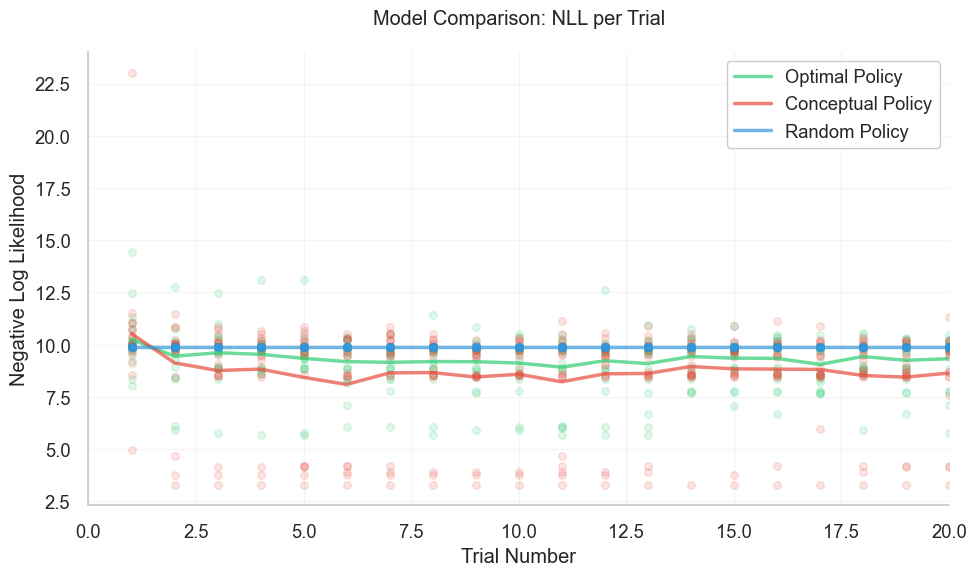

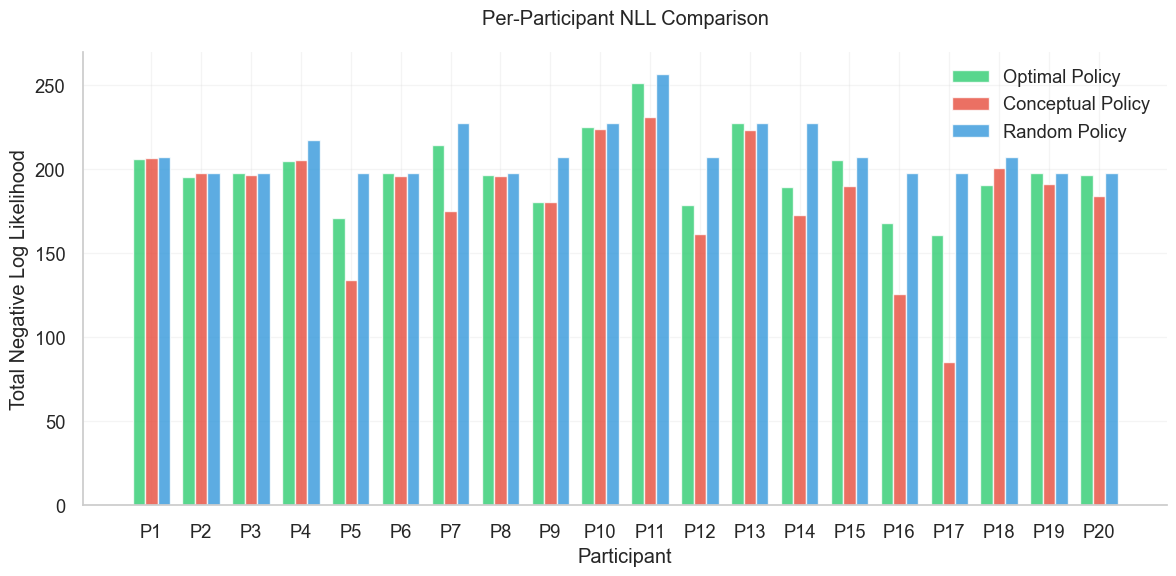


Mean NLL per trial:
Optimal Policy: 9.31
Conceptual Policy: 8.66
Random Policy: 9.89

Per-participant best fitting model:
Participant 1: Optimal model preferred
Participant 2: Optimal model preferred
Participant 3: Conceptual model preferred
Participant 4: Optimal model preferred
Participant 5: Conceptual model preferred
Participant 6: Conceptual model preferred
Participant 7: Conceptual model preferred
Participant 8: Conceptual model preferred
Participant 9: Conceptual model preferred
Participant 10: Conceptual model preferred
Participant 11: Conceptual model preferred
Participant 12: Conceptual model preferred
Participant 13: Conceptual model preferred
Participant 14: Conceptual model preferred
Participant 15: Conceptual model preferred
Participant 16: Conceptual model preferred
Participant 17: Conceptual model preferred
Participant 18: Optimal model preferred
Participant 19: Conceptual model preferred
Participant 20: Conceptual model preferred


In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# First plot: Trial-by-trial comparison
fig1, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = {
    'optimal': '#2ecc71',
    'conceptual': '#e74c3c',
    'random': '#3498db'
}

# Calculate trial means
trial_means = nll_data.groupby('trial_number').agg({
    'optimal_choice_nll': 'mean',
    'conceptual_choice_nll': 'mean',
    'random_choice_nll': 'mean'
}).reset_index()

# Plot mean lines first
ax.plot(trial_means['trial_number'], trial_means['optimal_choice_nll'], 
       '-', color=colors['optimal'], linewidth=2.5, alpha=0.7, label='Optimal Policy')
ax.plot(trial_means['trial_number'], trial_means['conceptual_choice_nll'], 
       '-', color=colors['conceptual'], linewidth=2.5, alpha=0.7, label='Conceptual Policy')
ax.plot(trial_means['trial_number'], trial_means['random_choice_nll'], 
       '-', color=colors['random'], linewidth=2.5, alpha=0.7, label='Random Policy')

# Plot individual points
ax.scatter(nll_data['trial_number'], nll_data['optimal_choice_nll'], 
         s=30, alpha=0.15, color=colors['optimal'])
ax.scatter(nll_data['trial_number'], nll_data['conceptual_choice_nll'], 
         s=30, alpha=0.15, color=colors['conceptual'])
ax.scatter(nll_data['trial_number'], nll_data['random_choice_nll'], 
         s=30, alpha=0.15, color=colors['random'])

# Clean up plot
ax.set_xlabel('Trial Number')
ax.set_ylabel('Negative Log Likelihood')
ax.set_title('Model Comparison: NLL per Trial', pad=20)
ax.legend(frameon=True, facecolor='white', framealpha=1)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 20)  # Cap x-axis at 20 trials

plt.tight_layout()
plt.savefig('figures/model_comparison_per_trial.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Second plot: Per-participant bar comparison
fig2, ax = plt.subplots(figsize=(12, 6))

# Calculate participant totals
participant_totals = nll_data.groupby('participant_id').agg({
    'optimal_choice_nll': 'sum',
    'conceptual_choice_nll': 'sum',
    'random_choice_nll': 'sum'
}).reset_index()

# Set up bars
x = np.arange(len(participant_totals))
width = 0.25

# Create bars
bars1 = ax.bar(x - width, participant_totals['optimal_choice_nll'], 
               width, label='Optimal Policy', color=colors['optimal'], alpha=0.8)
bars2 = ax.bar(x, participant_totals['conceptual_choice_nll'], 
               width, label='Conceptual Policy', color=colors['conceptual'], alpha=0.8)
bars3 = ax.bar(x + width, participant_totals['random_choice_nll'], 
               width, label='Random Policy', color=colors['random'], alpha=0.8)

# Clean up plot
ax.set_xlabel('Participant')
ax.set_ylabel('Total Negative Log Likelihood')
ax.set_title('Per-Participant NLL Comparison', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'P{i+1}' for i in range(len(participant_totals))])
ax.legend()
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/model_comparison_per_participant.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nMean NLL per trial:")
print(f"Optimal Policy: {nll_data['optimal_choice_nll'].mean():.2f}")
print(f"Conceptual Policy: {nll_data['conceptual_choice_nll'].mean():.2f}")
print(f"Random Policy: {nll_data['random_choice_nll'].mean():.2f}")

# Print per-participant statistics
print("\nPer-participant best fitting model:")
for idx, row in participant_totals.iterrows():
    nlls = {
        'Optimal': row['optimal_choice_nll'],
        'Conceptual': row['conceptual_choice_nll'],
        'Random': row['random_choice_nll']
    }
    best_model = min(nlls.items(), key=lambda x: x[1])[0]
    print(f"Participant {idx+1}: {best_model} model preferred")

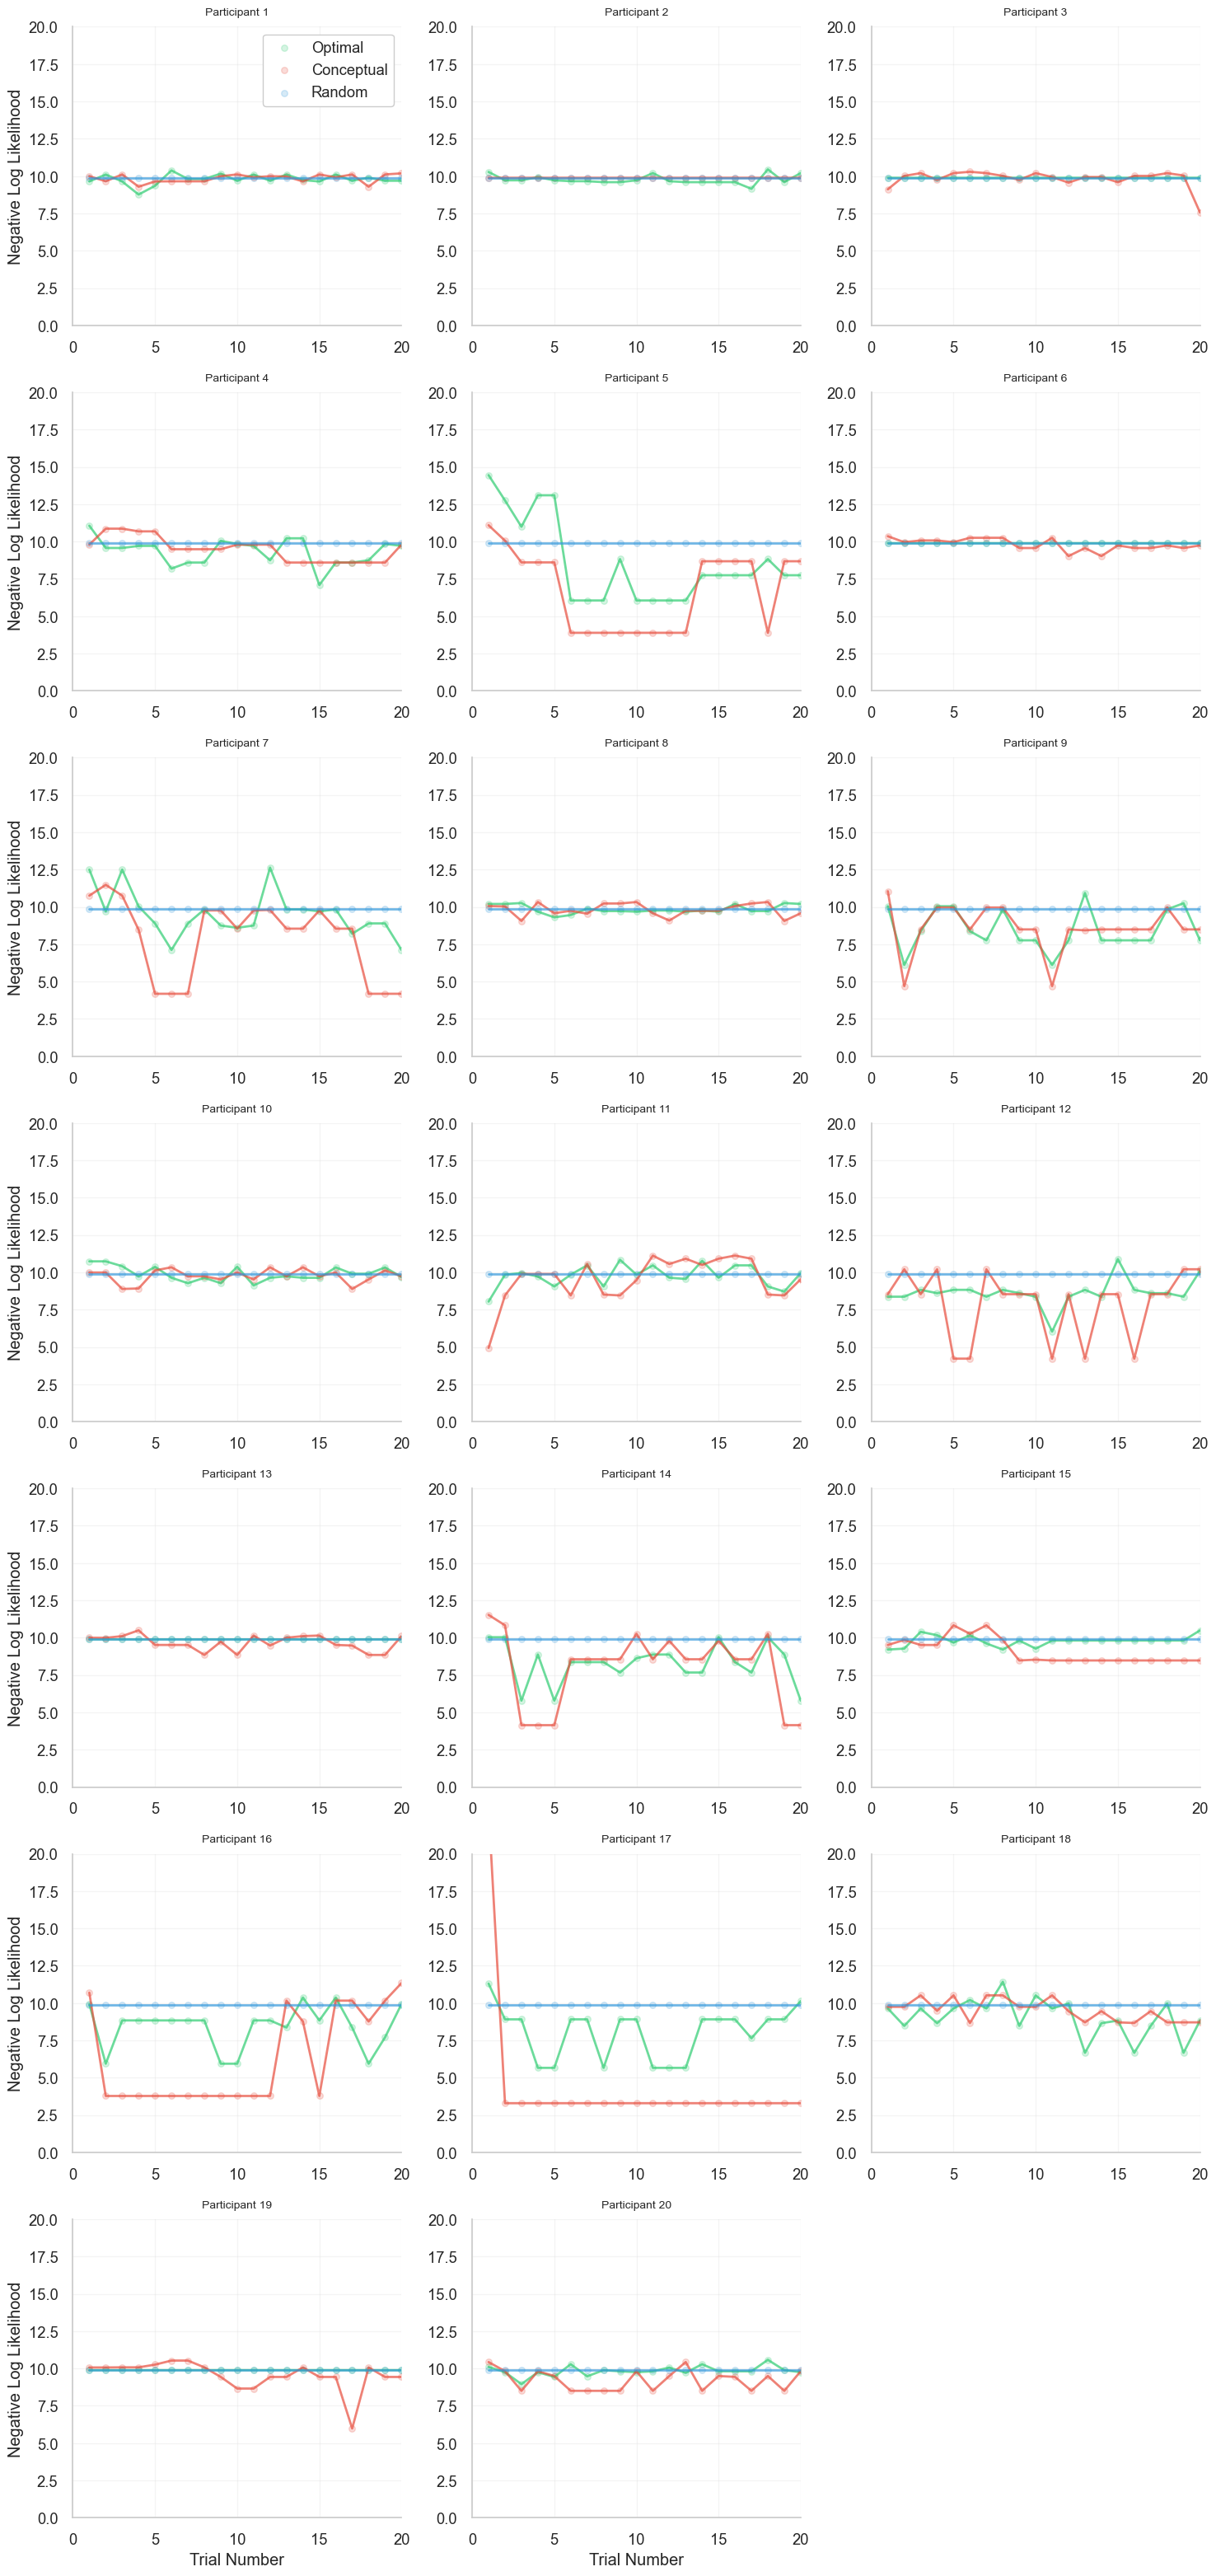

In [72]:
# Calculate and print per-participant faceted plot
n_participants = nll_data['participant_id'].nunique()
n_cols = 3
n_rows = (n_participants + n_cols - 1) // n_cols

fig3, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5*n_rows))
axes = axes.flatten()

for idx, (participant_id, participant_data) in enumerate(nll_data.groupby('participant_id')):
    ax = axes[idx]
    
    # Calculate means for this participant
    participant_means = participant_data.groupby('trial_number').agg({
        'optimal_choice_nll': 'mean',
        'conceptual_choice_nll': 'mean',
        'random_choice_nll': 'mean'
    }).reset_index()
    
    # Plot mean lines first
    ax.plot(participant_means['trial_number'], participant_means['optimal_choice_nll'],
           '-', color=colors['optimal'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['conceptual_choice_nll'],
           '-', color=colors['conceptual'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['random_choice_nll'],
           '-', color=colors['random'], linewidth=2, alpha=0.7)
    
    # Plot individual points
    ax.scatter(participant_data['trial_number'], participant_data['optimal_choice_nll'],
              s=30, alpha=0.2, color=colors['optimal'], label='Optimal')
    ax.scatter(participant_data['trial_number'], participant_data['conceptual_choice_nll'],
              s=30, alpha=0.2, color=colors['conceptual'], label='Conceptual')
    ax.scatter(participant_data['trial_number'], participant_data['random_choice_nll'],
              s=30, alpha=0.2, color=colors['random'], label='Random')
    
    # Calculate which model fits best
    nlls = {
        'Optimal': participant_data['optimal_choice_nll'].mean(),
        'Conceptual': participant_data['conceptual_choice_nll'].mean(),
        'Random': participant_data['random_choice_nll'].mean()
    }
    best_model = min(nlls.items(), key=lambda x: x[1])[0]
    
    # Clean up axes
    ax.set_xlabel('Trial Number' if idx >= len(axes) - n_cols else '')
    ax.set_ylabel('Negative Log Likelihood' if idx % n_cols == 0 else '')
    ax.set_title(f'Participant {idx+1}', fontsize=10, pad=10)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 20)  # Cap x-axis at 20 trials
    ax.set_ylim(0,20)  # Use same y-axis limits
    
    # Only add legend to first subplot
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=1)

# Remove any empty subplots
for idx in range(n_participants, len(axes)):
    fig3.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('figures/per_participant_faceted.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/qr/gb70fn114p97s4wfdyrjqlv40000gp/T/ipykernel_70214/3672218403.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


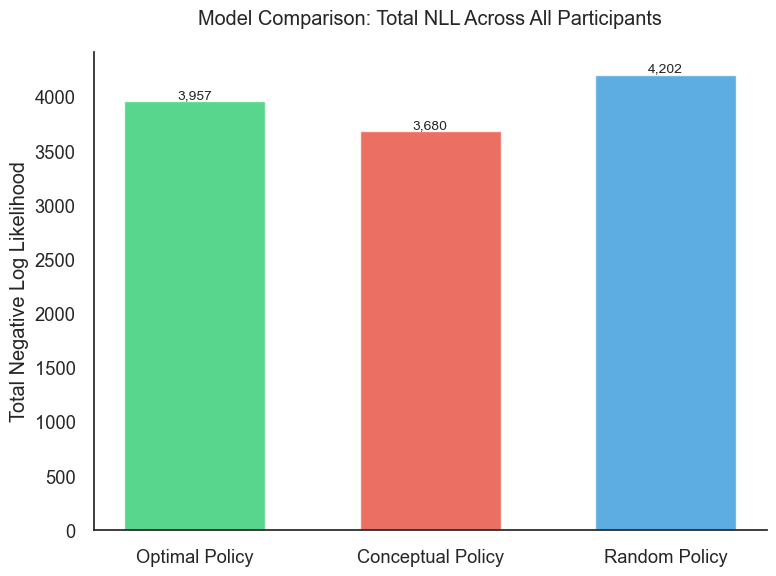


Total NLL:
Optimal Policy: 3,957
Conceptual Policy: 3,680
Random Policy: 4,202

Mean NLL per trial:
Optimal Policy: 9.31
Conceptual Policy: 8.66
Random Policy: 9.89


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean background
plt.style.use('seaborn')
sns.set_style("white")
sns.set_context("notebook", font_scale=1.2)

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# Calculate total NLLs
total_nlls = {
    'Optimal Policy': nll_data['optimal_choice_nll'].sum(),
    'Conceptual Policy': nll_data['conceptual_choice_nll'].sum(),
    'Random Policy': nll_data['random_choice_nll'].sum()
}

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors
colors = {
    'Optimal Policy': '#2ecc71',
    'Conceptual Policy': '#e74c3c',
    'Random Policy': '#3498db'
}

# Create bars
bars = ax.bar(total_nlls.keys(), total_nlls.values(), 
              color=[colors[k] for k in total_nlls.keys()], 
              alpha=0.8, width=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}',
            ha='center', va='bottom', fontsize=10)

# Clean up plot
ax.set_ylabel('Total Negative Log Likelihood')
ax.set_title('Model Comparison: Total NLL Across All Participants', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save and show plot
plt.savefig('figures/overall_model_comparison.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nTotal NLL:")
for model, total in total_nlls.items():
    print(f"{model}: {total:,.0f}")

print("\nMean NLL per trial:")
print(f"Optimal Policy: {nll_data['optimal_choice_nll'].mean():.2f}")
print(f"Conceptual Policy: {nll_data['conceptual_choice_nll'].mean():.2f}")
print(f"Random Policy: {nll_data['random_choice_nll'].mean():.2f}")

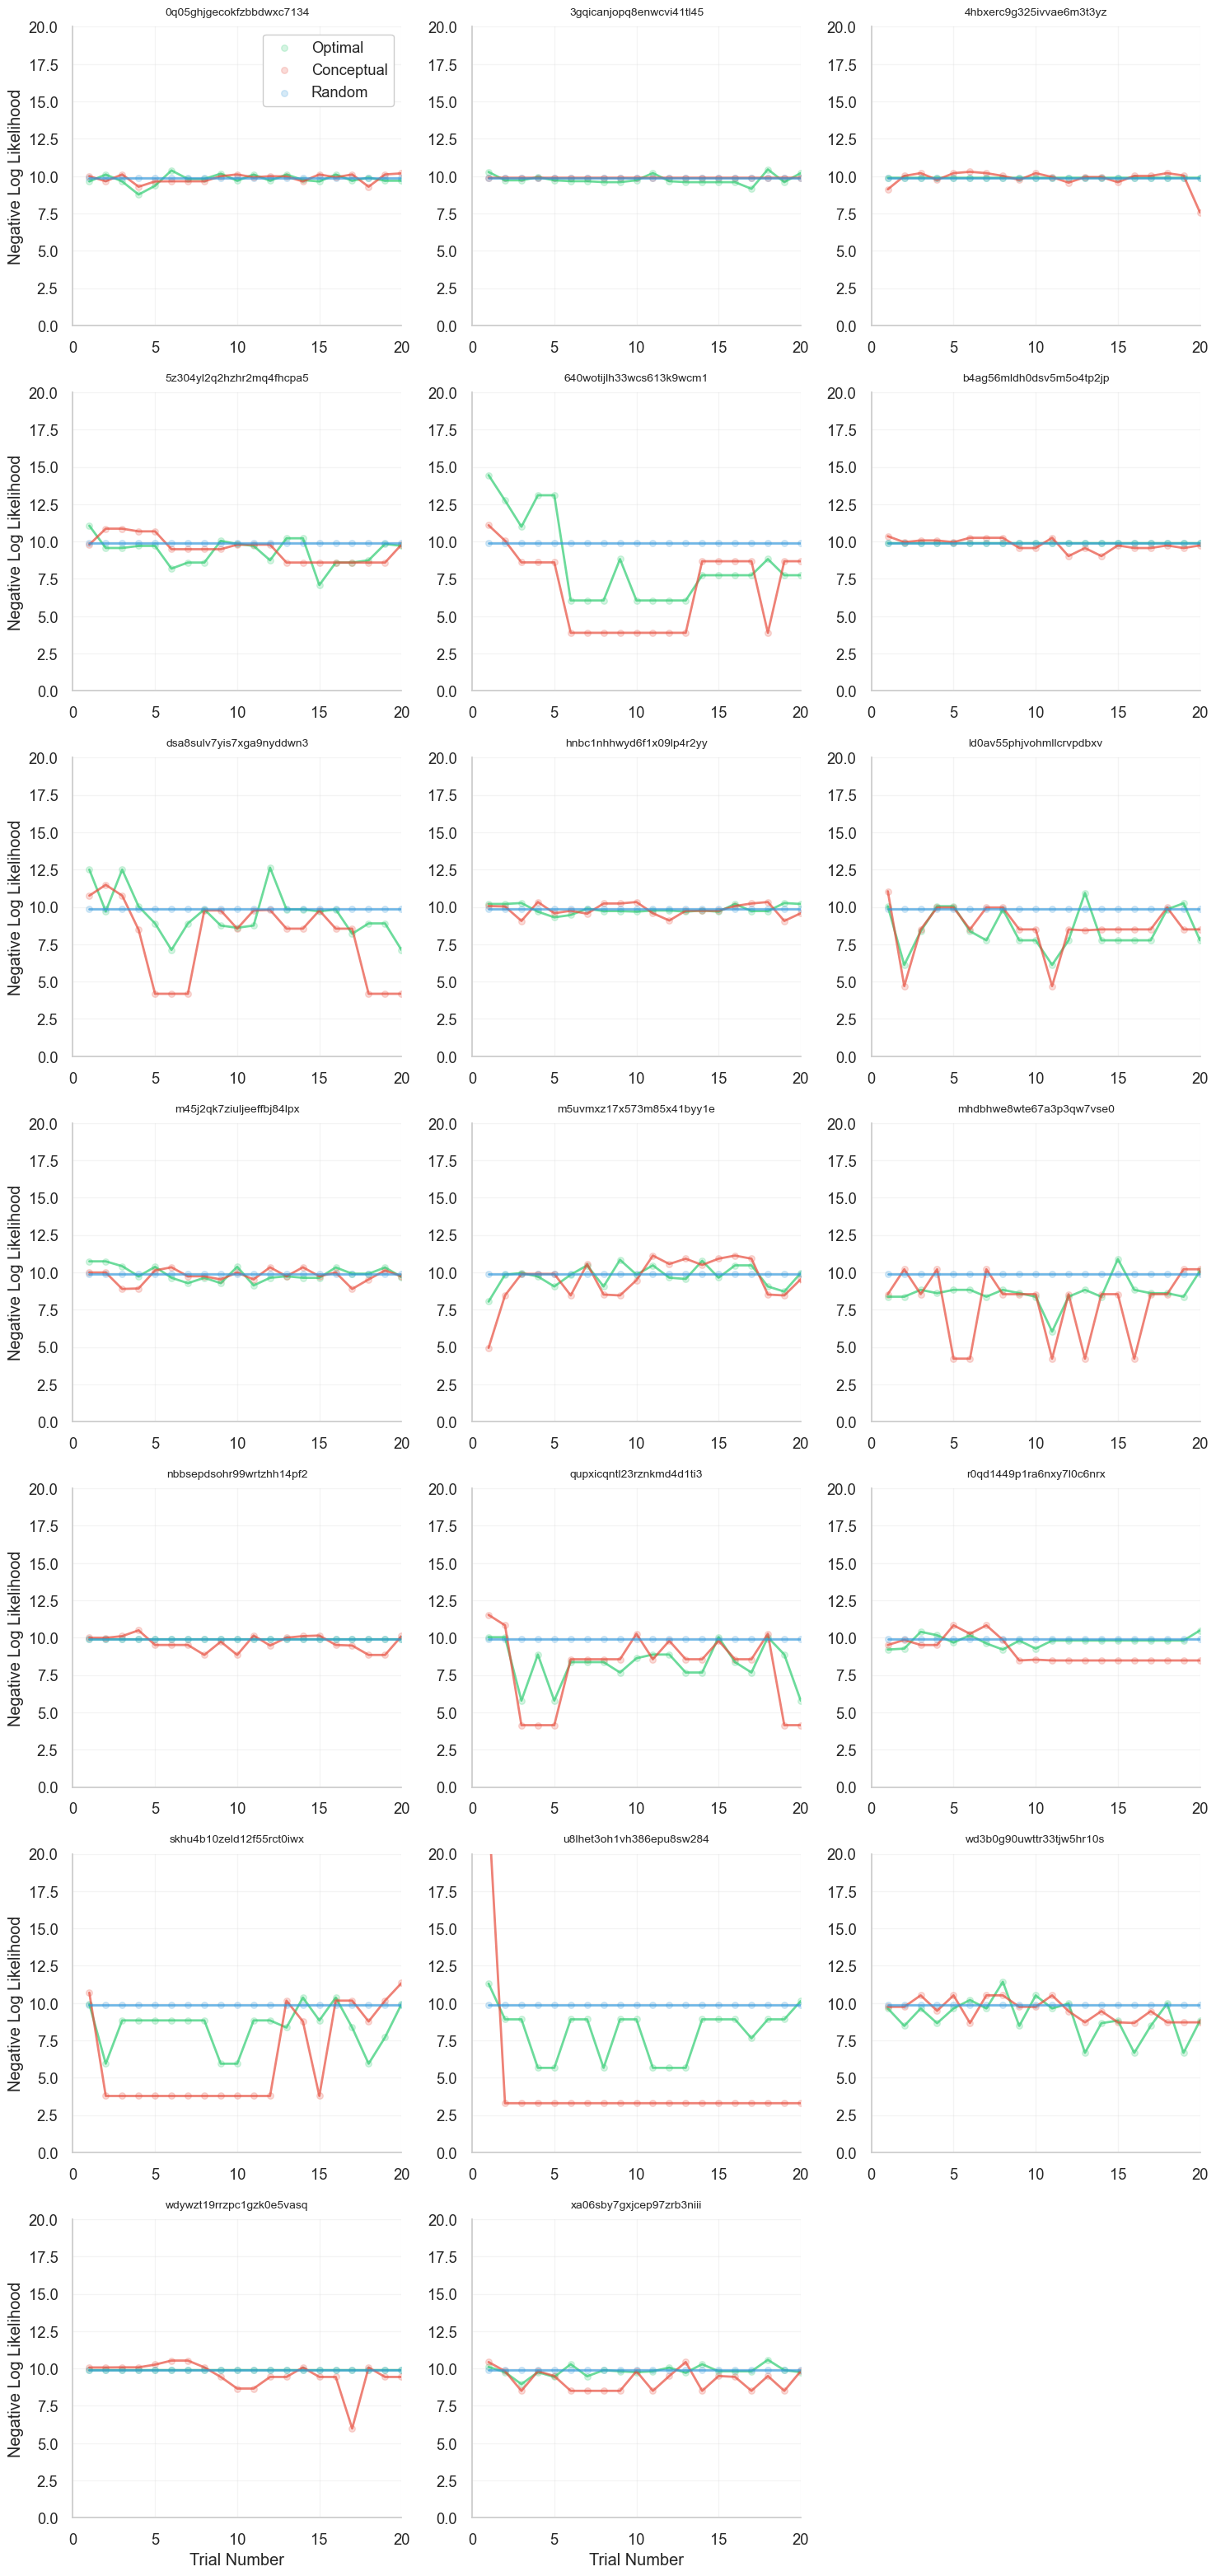

In [77]:
# Calculate and print per-participant faceted plot
n_participants = nll_data['participant_id'].nunique()
n_cols = 3
n_rows = (n_participants + n_cols - 1) // n_cols

fig3, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5*n_rows))
axes = axes.flatten()

for idx, (participant_id, participant_data) in enumerate(nll_data.groupby('participant_id')):
    ax = axes[idx]
    
    # Calculate means for this participant
    participant_means = participant_data.groupby('trial_number').agg({
        'optimal_choice_nll': 'mean',
        'conceptual_choice_nll': 'mean',
        'random_choice_nll': 'mean'
    }).reset_index()
    
    # Plot mean lines first
    ax.plot(participant_means['trial_number'], participant_means['optimal_choice_nll'],
           '-', color=colors['optimal'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['conceptual_choice_nll'],
           '-', color=colors['conceptual'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['random_choice_nll'],
           '-', color=colors['random'], linewidth=2, alpha=0.7)
    
    # Plot individual points
    ax.scatter(participant_data['trial_number'], participant_data['optimal_choice_nll'],
              s=30, alpha=0.2, color=colors['optimal'], label='Optimal')
    ax.scatter(participant_data['trial_number'], participant_data['conceptual_choice_nll'],
              s=30, alpha=0.2, color=colors['conceptual'], label='Conceptual')
    ax.scatter(participant_data['trial_number'], participant_data['random_choice_nll'],
              s=30, alpha=0.2, color=colors['random'], label='Random')
    
    # Calculate which model fits best
    nlls = {
        'Optimal': participant_data['optimal_choice_nll'].mean(),
        'Conceptual': participant_data['conceptual_choice_nll'].mean(),
        'Random': participant_data['random_choice_nll'].mean()
    }
    best_model = min(nlls.items(), key=lambda x: x[1])[0]
    
    # Clean up axes
    ax.set_xlabel('Trial Number' if idx >= len(axes) - n_cols else '')
    ax.set_ylabel('Negative Log Likelihood' if idx % n_cols == 0 else '')
    
    # Use participant ID instead of "Participant N"
    ax.set_title(f'{participant_id}', fontsize=10, pad=10)
    
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 20)  # Cap x-axis at 20 trials
    ax.set_ylim(0,20)  # Use same y-axis limits
    
    # Only add legend to first subplot
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=1)

# Remove any empty subplots
for idx in range(n_participants, len(axes)):
    fig3.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('figures/per_participant_faceted.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/qr/gb70fn114p97s4wfdyrjqlv40000gp/T/ipykernel_22201/2271768791.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


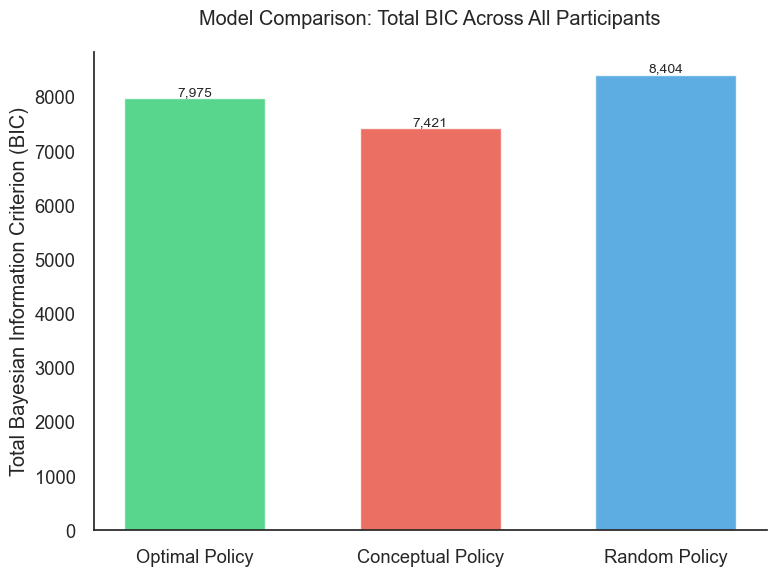


Total BIC:
Optimal Policy: 7,975
Conceptual Policy: 7,421
Random Policy: 8,404

Mean BIC per trial:
Optimal Policy: 18.76
Conceptual Policy: 17.46
Random Policy: 19.78


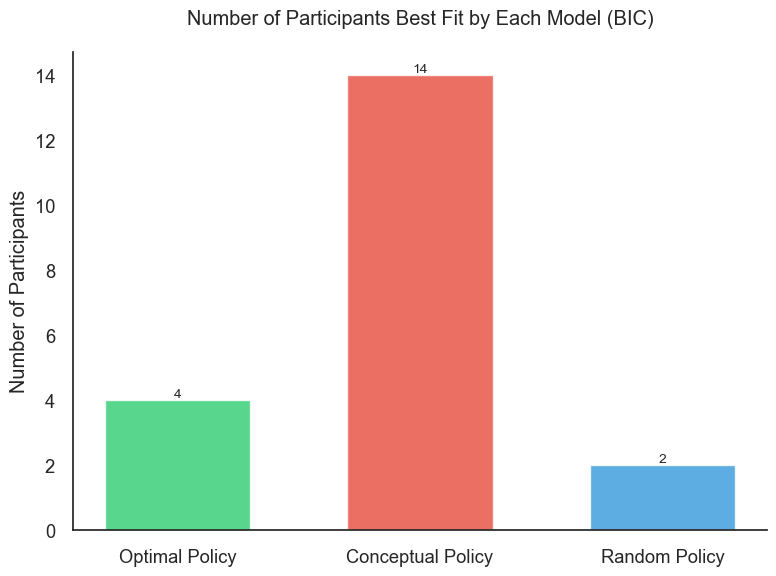


Number of participants best fit by each model (BIC):
Optimal Policy: 4
Conceptual Policy: 14
Random Policy: 2


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean background
plt.style.use('seaborn')
sns.set_style("white")
sns.set_context("notebook", font_scale=1.2)

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# Calculate total BICs
total_bics = {
    'Optimal Policy': nll_data['optimal_choice_bic'].sum(),
    'Conceptual Policy': nll_data['conceptual_choice_bic'].sum(),
    'Random Policy': nll_data['random_choice_bic'].sum()
}

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors
colors = {
    'Optimal Policy': '#2ecc71',
    'Conceptual Policy': '#e74c3c',
    'Random Policy': '#3498db'
}

# Create bars
bars = ax.bar(total_bics.keys(), total_bics.values(), 
              color=[colors[k] for k in total_bics.keys()], 
              alpha=0.8, width=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}',
            ha='center', va='bottom', fontsize=10)

# Clean up plot
ax.set_ylabel('Total Bayesian Information Criterion (BIC)')
ax.set_title('Model Comparison: Total BIC Across All Participants', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save and show plot
plt.savefig('figures/overall_model_comparison_bic.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nTotal BIC:")
for model, total in total_bics.items():
    print(f"{model}: {total:,.0f}")

print("\nMean BIC per trial:")
print(f"Optimal Policy: {nll_data['optimal_choice_bic'].mean():.2f}")
print(f"Conceptual Policy: {nll_data['conceptual_choice_bic'].mean():.2f}")
print(f"Random Policy: {nll_data['random_choice_bic'].mean():.2f}")

# Also create a per-participant BIC comparison
participant_bics = nll_data.groupby('participant_id').agg({
    'optimal_total_bic': 'first',
    'conceptual_total_bic': 'first',
    'random_total_bic': 'first'
}).reset_index()

# Count how many participants are best fit by each model
best_model_counts = {
    'Optimal Policy': 0,
    'Conceptual Policy': 0,
    'Random Policy': 0
}

for _, row in participant_bics.iterrows():
    bics = {
        'Optimal Policy': row['optimal_total_bic'],
        'Conceptual Policy': row['conceptual_total_bic'],
        'Random Policy': row['random_total_bic']
    }
    best_model = min(bics.items(), key=lambda x: x[1])[0]
    best_model_counts[best_model] += 1

# Create figure for best model counts
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Create bars for best model counts
bars2 = ax2.bar(best_model_counts.keys(), best_model_counts.values(), 
               color=[colors[k] for k in best_model_counts.keys()], 
               alpha=0.8, width=0.6)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom', fontsize=10)

# Clean up plot
ax2.set_ylabel('Number of Participants')
ax2.set_title('Number of Participants Best Fit by Each Model (BIC)', pad=20)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save and show plot
plt.savefig('figures/best_model_counts_bic.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print best model counts
print("\nNumber of participants best fit by each model (BIC):")
for model, count in best_model_counts.items():
    print(f"{model}: {count}")

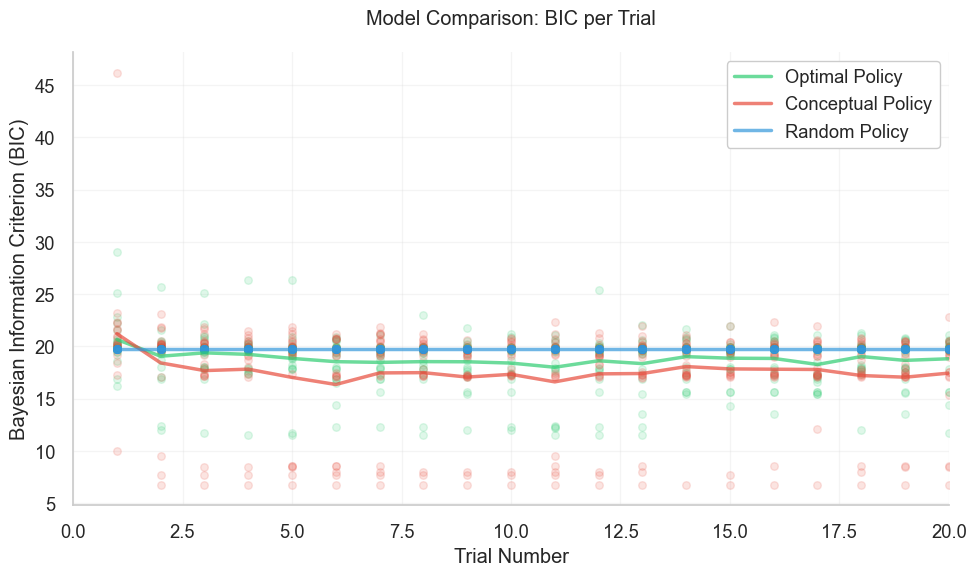

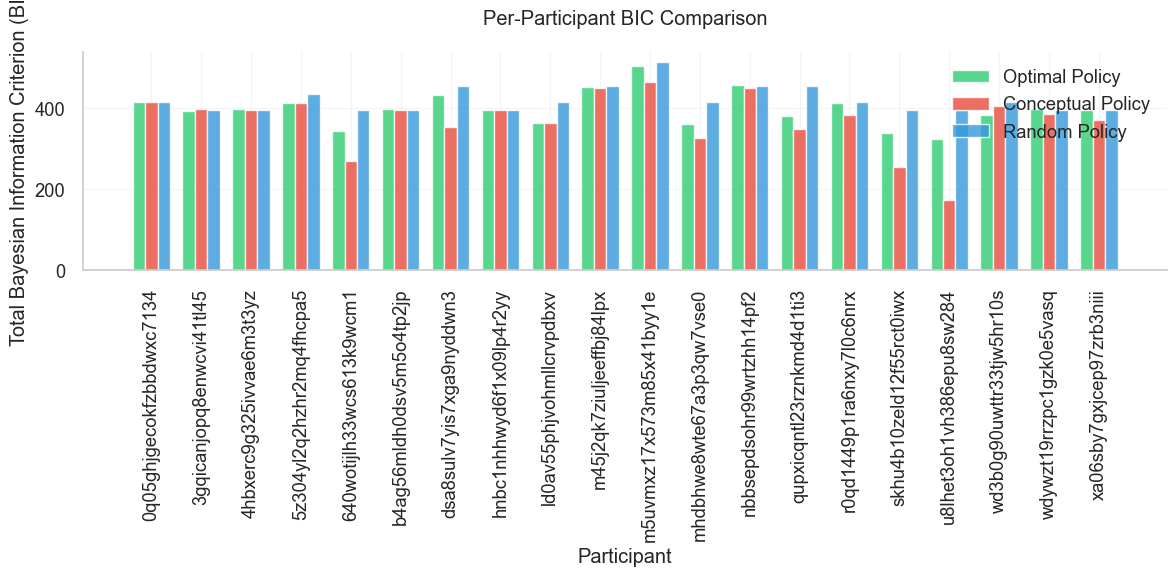


Mean BIC per trial:
Optimal Policy: 18.76
Conceptual Policy: 17.46
Random Policy: 19.78

Per-participant best fitting model (BIC):
Participant 0q05ghjgecokfzbbdwxc7134: Optimal model preferred (BIC values: Optimal=415.17, Conceptual=417.04, Random=415.28)
Participant 3gqicanjopq8enwcvi41tl45: Optimal model preferred (BIC values: Optimal=393.50, Conceptual=398.50, Random=395.50)
Participant 4hbxerc9g325ivvae6m3t3yz: Random model preferred (BIC values: Optimal=398.50, Conceptual=396.07, Random=395.50)
Participant 5z304yl2q2hzhr2mq4fhcpa5: Optimal model preferred (BIC values: Optimal=412.88, Conceptual=413.88, Random=435.05)
Participant 640wotijlh33wcs613k9wcm1: Conceptual model preferred (BIC values: Optimal=344.67, Conceptual=271.02, Random=395.50)
Participant b4ag56mldh0dsv5m5o4tp2jp: Conceptual model preferred (BIC values: Optimal=398.50, Conceptual=395.10, Random=395.50)
Participant dsa8sulv7yis7xga9nyddwn3: Conceptual model preferred (BIC values: Optimal=432.29, Conceptual=353.20, 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# First plot: Trial-by-trial BIC comparison
fig1, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = {
    'optimal': '#2ecc71',
    'conceptual': '#e74c3c',
    'random': '#3498db'
}

# Calculate trial means for BIC
trial_means = nll_data.groupby('trial_number').agg({
    'optimal_choice_bic': 'mean',
    'conceptual_choice_bic': 'mean',
    'random_choice_bic': 'mean'
}).reset_index()

# Plot mean lines first
ax.plot(trial_means['trial_number'], trial_means['optimal_choice_bic'], 
       '-', color=colors['optimal'], linewidth=2.5, alpha=0.7, label='Optimal Policy')
ax.plot(trial_means['trial_number'], trial_means['conceptual_choice_bic'], 
       '-', color=colors['conceptual'], linewidth=2.5, alpha=0.7, label='Conceptual Policy')
ax.plot(trial_means['trial_number'], trial_means['random_choice_bic'], 
       '-', color=colors['random'], linewidth=2.5, alpha=0.7, label='Random Policy')

# Plot individual points
ax.scatter(nll_data['trial_number'], nll_data['optimal_choice_bic'], 
         s=30, alpha=0.15, color=colors['optimal'])
ax.scatter(nll_data['trial_number'], nll_data['conceptual_choice_bic'], 
         s=30, alpha=0.15, color=colors['conceptual'])
ax.scatter(nll_data['trial_number'], nll_data['random_choice_bic'], 
         s=30, alpha=0.15, color=colors['random'])

# Clean up plot
ax.set_xlabel('Trial Number')
ax.set_ylabel('Bayesian Information Criterion (BIC)')
ax.set_title('Model Comparison: BIC per Trial', pad=20)
ax.legend(frameon=True, facecolor='white', framealpha=1)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 20)  # Cap x-axis at 20 trials

plt.tight_layout()
plt.savefig('figures/model_comparison_bic_per_trial.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Second plot: Per-participant bar comparison using BIC
fig2, ax = plt.subplots(figsize=(12, 6))

# Calculate participant totals for BIC
participant_totals = nll_data.groupby('participant_id').agg({
    'optimal_total_bic': 'first',  # Use first() since total_bic is the same for all trials per participant
    'conceptual_total_bic': 'first',
    'random_total_bic': 'first'
}).reset_index()

# Set up bars
x = np.arange(len(participant_totals))
width = 0.25

# Create bars
bars1 = ax.bar(x - width, participant_totals['optimal_total_bic'], 
               width, label='Optimal Policy', color=colors['optimal'], alpha=0.8)
bars2 = ax.bar(x, participant_totals['conceptual_total_bic'], 
               width, label='Conceptual Policy', color=colors['conceptual'], alpha=0.8)
bars3 = ax.bar(x + width, participant_totals['random_total_bic'], 
               width, label='Random Policy', color=colors['random'], alpha=0.8)

# Clean up plot
ax.set_xlabel('Participant')
ax.set_ylabel('Total Bayesian Information Criterion (BIC)')
ax.set_title('Per-Participant BIC Comparison', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(participant_totals['participant_id'], rotation=90)
ax.legend()
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add more space at the bottom for the rotated labels
plt.subplots_adjust(bottom=0.3)

plt.tight_layout()
plt.savefig('figures/model_comparison_bic_per_participant.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics for BIC
print("\nMean BIC per trial:")
print(f"Optimal Policy: {nll_data['optimal_choice_bic'].mean():.2f}")
print(f"Conceptual Policy: {nll_data['conceptual_choice_bic'].mean():.2f}")
print(f"Random Policy: {nll_data['random_choice_bic'].mean():.2f}")

# Print per-participant statistics using BIC
print("\nPer-participant best fitting model (BIC):")
for _, row in participant_totals.iterrows():
    bics = {
        'Optimal': row['optimal_total_bic'],
        'Conceptual': row['conceptual_total_bic'],
        'Random': row['random_total_bic']
    }
    best_model = min(bics.items(), key=lambda x: x[1])[0]
    print(f"Participant {row['participant_id']}: {best_model} model preferred (BIC values: Optimal={row['optimal_total_bic']:.2f}, Conceptual={row['conceptual_total_bic']:.2f}, Random={row['random_total_bic']:.2f})")

# Add a summary of how many participants are best fit by each model
model_counts = {'Optimal': 0, 'Conceptual': 0, 'Random': 0}
for _, row in participant_totals.iterrows():
    bics = {
        'Optimal': row['optimal_total_bic'],
        'Conceptual': row['conceptual_total_bic'],
        'Random': row['random_total_bic']
    }
    best_model = min(bics.items(), key=lambda x: x[1])[0]
    model_counts[best_model] += 1

print("\nSummary of best fitting models (BIC):")
for model, count in model_counts.items():
    print(f"{model} Policy: {count} participants")

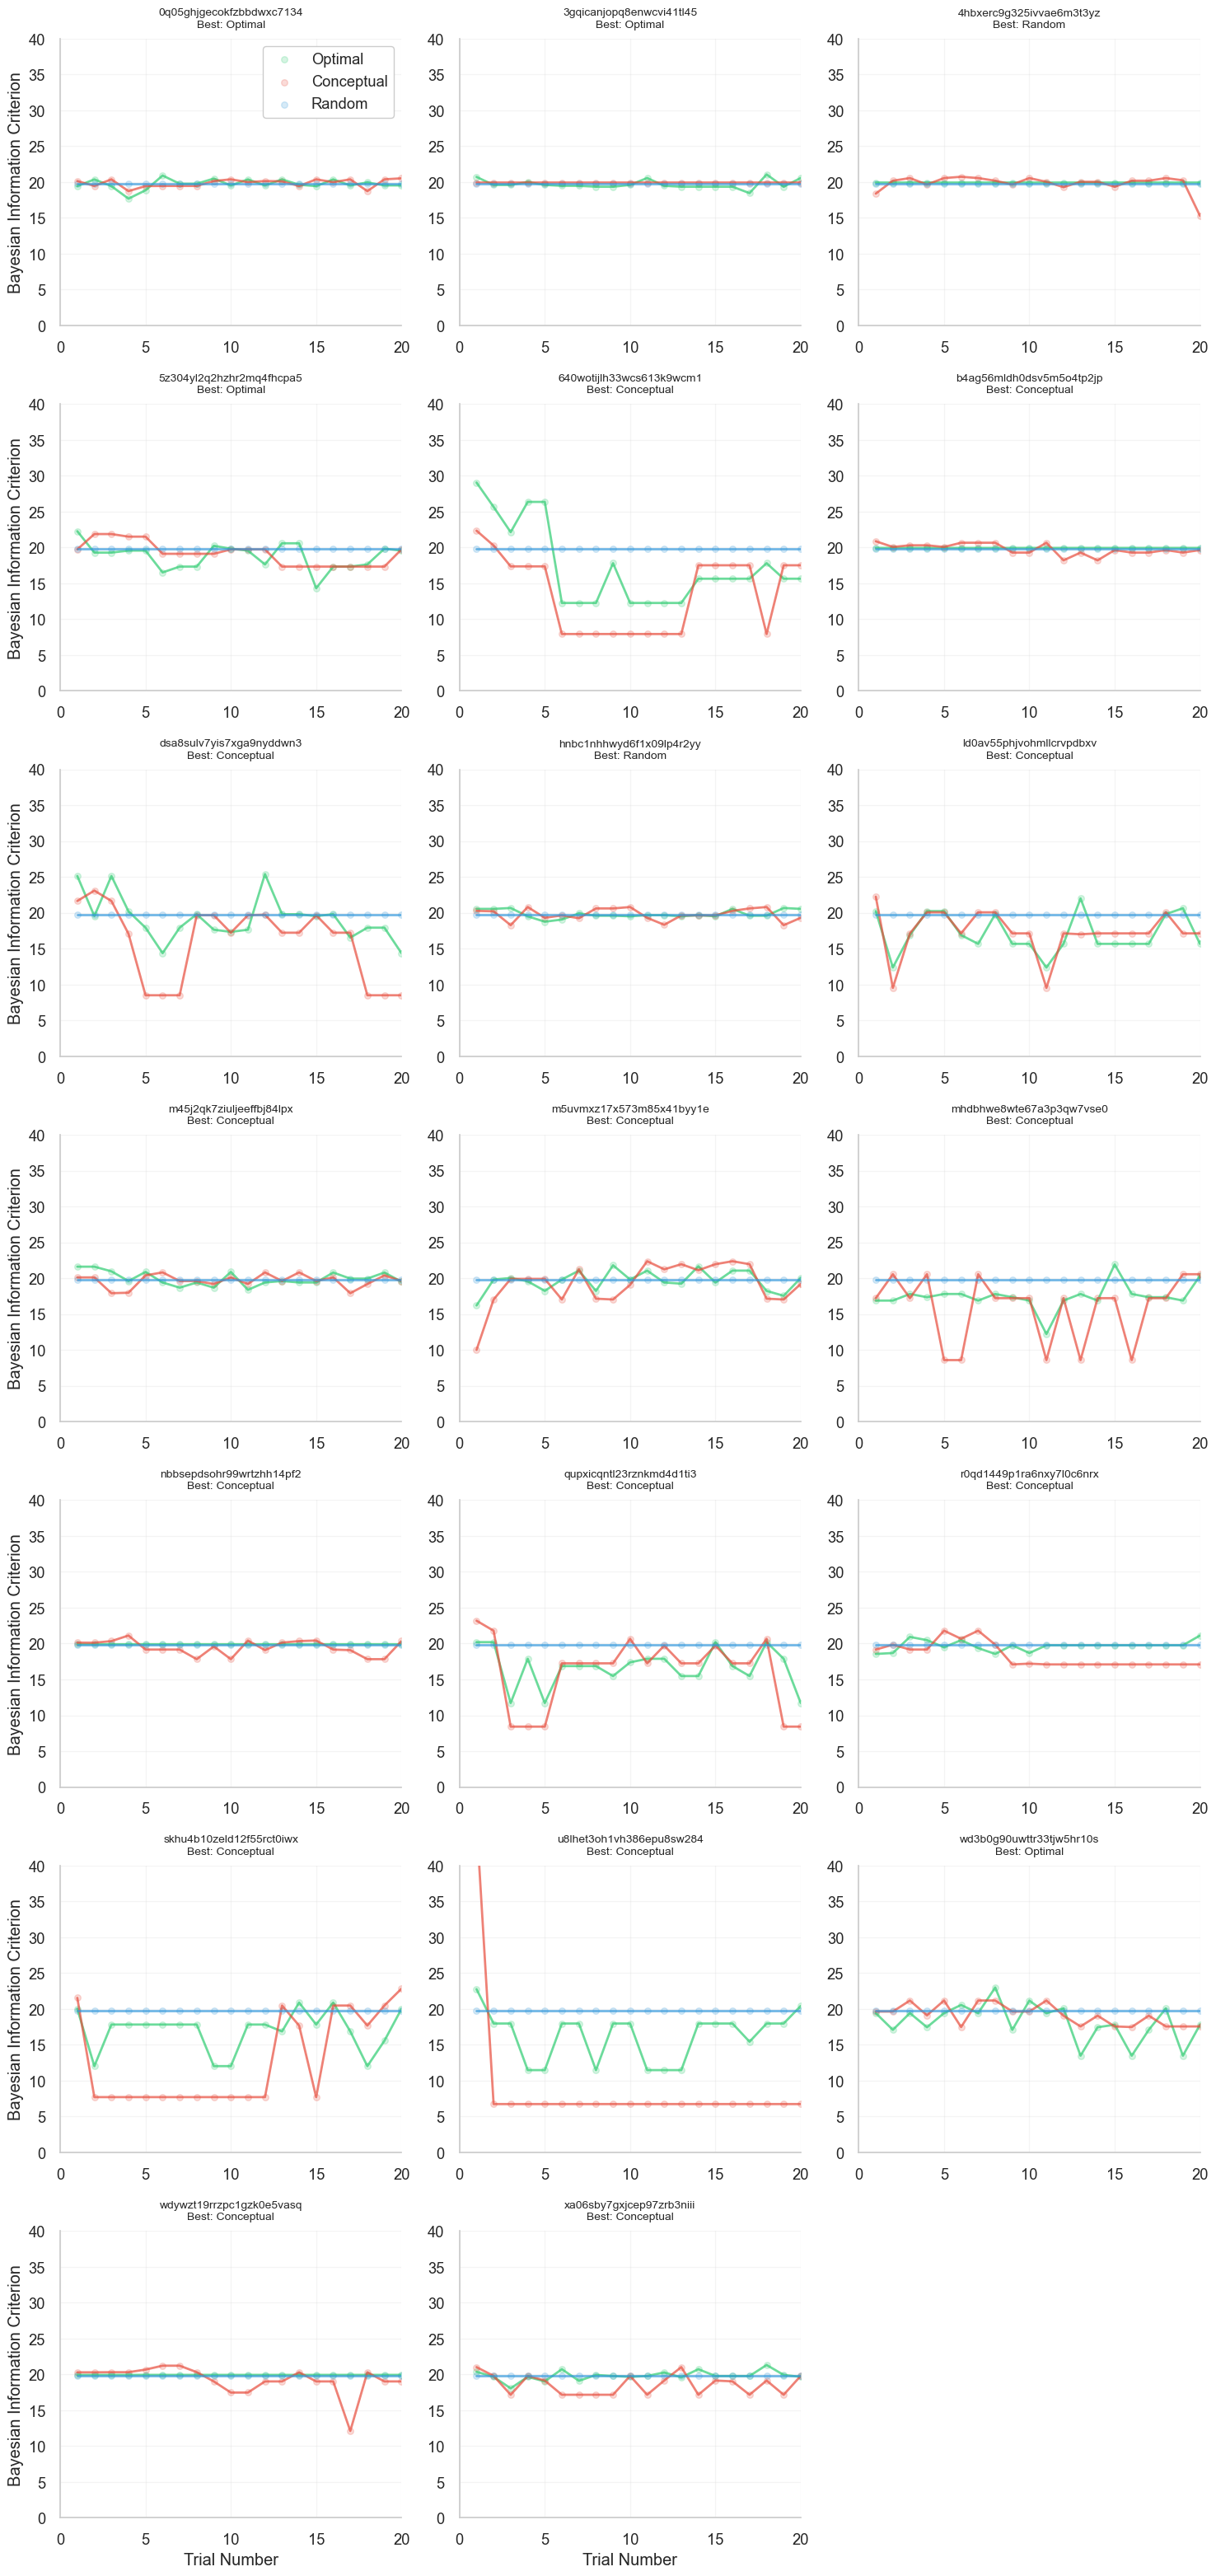


Best model per participant according to BIC:
0q05ghjgecokfzbbdwxc7134: Optimal model preferred (BIC values: Optimal=415.17, Conceptual=417.04, Random=415.28)
3gqicanjopq8enwcvi41tl45: Optimal model preferred (BIC values: Optimal=393.50, Conceptual=398.50, Random=395.50)
4hbxerc9g325ivvae6m3t3yz: Random model preferred (BIC values: Optimal=398.50, Conceptual=396.07, Random=395.50)
5z304yl2q2hzhr2mq4fhcpa5: Optimal model preferred (BIC values: Optimal=412.88, Conceptual=413.88, Random=435.05)
640wotijlh33wcs613k9wcm1: Conceptual model preferred (BIC values: Optimal=344.67, Conceptual=271.02, Random=395.50)
b4ag56mldh0dsv5m5o4tp2jp: Conceptual model preferred (BIC values: Optimal=398.50, Conceptual=395.10, Random=395.50)
dsa8sulv7yis7xga9nyddwn3: Conceptual model preferred (BIC values: Optimal=432.29, Conceptual=353.20, Random=454.83)
hnbc1nhhwyd6f1x09lp4r2yy: Random model preferred (BIC values: Optimal=396.65, Conceptual=395.53, Random=395.50)
ld0av55phjvohmllcrvpdbxv: Conceptual model 

In [3]:
# Calculate and print per-participant faceted plot using BIC
n_participants = nll_data['participant_id'].nunique()
n_cols = 3
n_rows = (n_participants + n_cols - 1) // n_cols

fig3, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5*n_rows))
axes = axes.flatten()

for idx, (participant_id, participant_data) in enumerate(nll_data.groupby('participant_id')):
    ax = axes[idx]
    
    # Calculate means for this participant using BIC
    participant_means = participant_data.groupby('trial_number').agg({
        'optimal_choice_bic': 'mean',
        'conceptual_choice_bic': 'mean',
        'random_choice_bic': 'mean'
    }).reset_index()
    
    # Plot mean lines first
    ax.plot(participant_means['trial_number'], participant_means['optimal_choice_bic'],
           '-', color=colors['optimal'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['conceptual_choice_bic'],
           '-', color=colors['conceptual'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['random_choice_bic'],
           '-', color=colors['random'], linewidth=2, alpha=0.7)
    
    # Plot individual points
    ax.scatter(participant_data['trial_number'], participant_data['optimal_choice_bic'],
              s=30, alpha=0.2, color=colors['optimal'], label='Optimal')
    ax.scatter(participant_data['trial_number'], participant_data['conceptual_choice_bic'],
              s=30, alpha=0.2, color=colors['conceptual'], label='Conceptual')
    ax.scatter(participant_data['trial_number'], participant_data['random_choice_bic'],
              s=30, alpha=0.2, color=colors['random'], label='Random')
    
    # Calculate which model fits best using BIC
    bics = {
        'Optimal': participant_data['optimal_total_bic'].iloc[0],  # Use first value since total_bic is the same for all trials
        'Conceptual': participant_data['conceptual_total_bic'].iloc[0],
        'Random': participant_data['random_total_bic'].iloc[0]
    }
    best_model = min(bics.items(), key=lambda x: x[1])[0]
    
    # Clean up axes
    ax.set_xlabel('Trial Number' if idx >= len(axes) - n_cols else '')
    ax.set_ylabel('Bayesian Information Criterion' if idx % n_cols == 0 else '')
    
    # Use participant ID and indicate best model
    ax.set_title(f'{participant_id}\nBest: {best_model}', fontsize=10, pad=10)
    
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 20)  # Cap x-axis at 20 trials
    
    # Adjust y-axis limits for BIC values which might be higher than NLL
    ax.set_ylim(0, 40)  # Increased upper limit for BIC values
    
    # Only add legend to first subplot
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=1)

# Remove any empty subplots
for idx in range(n_participants, len(axes)):
    fig3.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('figures/per_participant_faceted_bic.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# Print summary of best models according to BIC
print("\nBest model per participant according to BIC:")
for participant_id, participant_data in nll_data.groupby('participant_id'):
    # Get the total BIC values for this participant
    bics = {
        'Optimal': participant_data['optimal_total_bic'].iloc[0],
        'Conceptual': participant_data['conceptual_total_bic'].iloc[0],
        'Random': participant_data['random_total_bic'].iloc[0]
    }
    best_model = min(bics.items(), key=lambda x: x[1])[0]
    bic_values = f"Optimal={bics['Optimal']:.2f}, Conceptual={bics['Conceptual']:.2f}, Random={bics['Random']:.2f}"
    print(f"{participant_id}: {best_model} model preferred (BIC values: {bic_values})")

# Cost of Goal Pursuit

In [45]:
def find_goal_index(row, conceptual_probs_df):
    """Find the index of a goal configuration in the conceptual probabilities dataframe."""
    # Create query for each shape
    query = True
    for i in range(3):  # For each shape position
        for prop in ['type', 'shade', 'texture']:
            # Map column names between dataframes
            selected_col = f'shape_{i}_{prop}'
            prob_col = f'shape{i+1}_{"sides" if prop == "type" else prop}'
            
            value = row[selected_col]
            query &= (conceptual_probs_df[prob_col] == value)
    
    matching_rows = conceptual_probs_df[query]
    
    if len(matching_rows) == 0:
        print(f"\nNo matching configuration found for:")
        print(f"Participant: {row['participant_id']}, Trial: {row['trial_number']}")
        for i in range(3):
            print(f"Shape {i}: {row[f'shape_{i}_type']}, {row[f'shape_{i}_shade']}, {row[f'shape_{i}_texture']}")
        raise ValueError("No matching configuration found in conceptual probabilities")
    
    return matching_rows.index[0]



In [46]:
# Read in the values for the goal pursuit cost
value_function = pd.read_csv('../simulations/value-functions/goal_value_function_mean.csv')

# Remove summary rows from value function
value_function = value_function[value_function['shape1_sides'] != 'SUMMARY']

# For each selected goal, find the average cost
costs = []
for _, row in selected_goals.iterrows():
    goal_index = find_goal_index(row, value_function)
    cost = value_function.loc[goal_index, 'value']
    costs.append(cost)

# Add the costs to the selected goals dataframe
selected_goals['cost'] = -1 * np.array(costs)



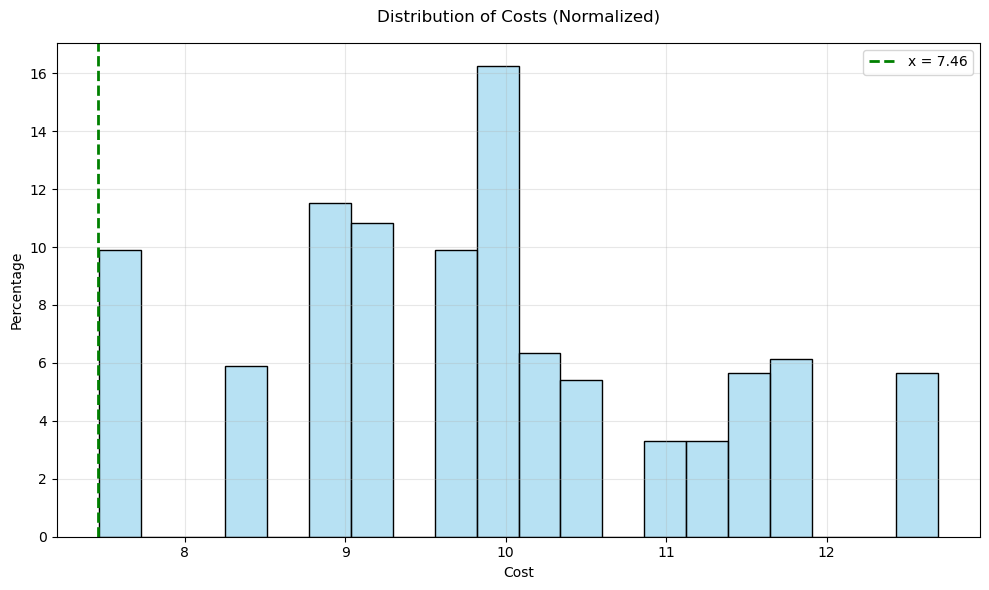

In [47]:
# Alternative version with percentages
plt.figure(figsize=(10, 6))
sns.histplot(
    data=selected_goals, 
    x='cost', 
    bins=20, 
    color='skyblue', 
    alpha=0.6, 
    edgecolor='black',
    stat='percent'  # This shows percentages instead of proportions
)

# Add vertical line at 7.46
plt.axvline(x=7.46, color='green', linestyle='--', linewidth=2, label='x = 7.46')

# Customize the plot
plt.title('Distribution of Costs (Normalized)', fontsize=12, pad=15)
plt.xlabel('Cost', fontsize=10)
plt.ylabel('Percentage', fontsize=10)  # Changed to 'Percentage'
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()





2025-04-29 13:40:07,800 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


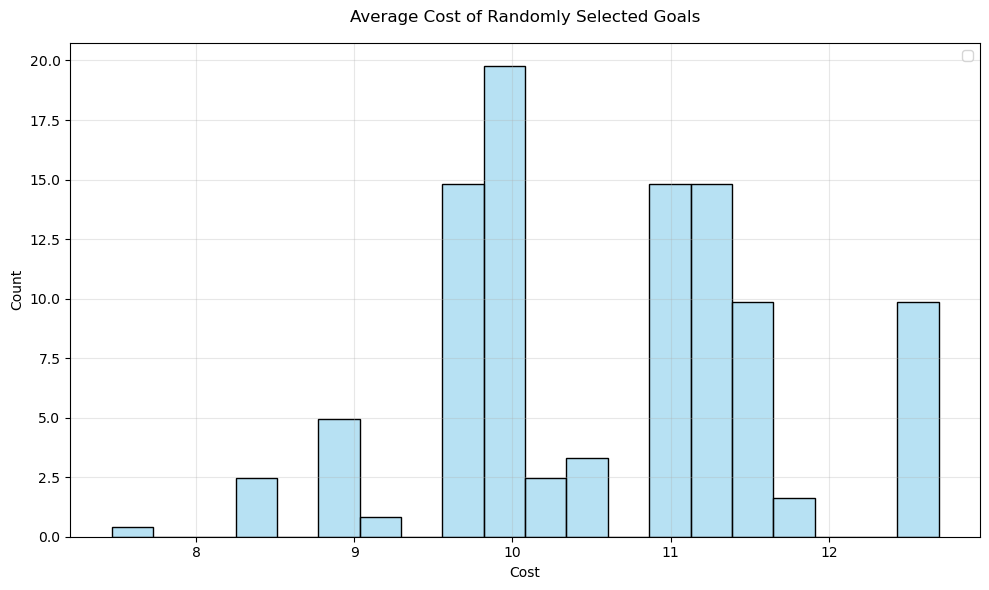

In [144]:
# take the negative of the value function
value_function['value'] = -1 * value_function['value']

# plot a histogram of the costs of all goals
plt.figure(figsize=(10, 6))
sns.histplot(data=value_function, x = 'value', bins=20, color='skyblue', alpha=0.6, edgecolor='black', stat='percent')

# Add vertical line at 7.46
# plt.axvline(x=7.46, color='green', linestyle='--', linewidth=2, label='Cost of Optimal Policy')

# Customize the plot12
plt.title('Average Cost of Randomly Selected Goals', fontsize=12, pad=15)
plt.xlabel('Cost', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

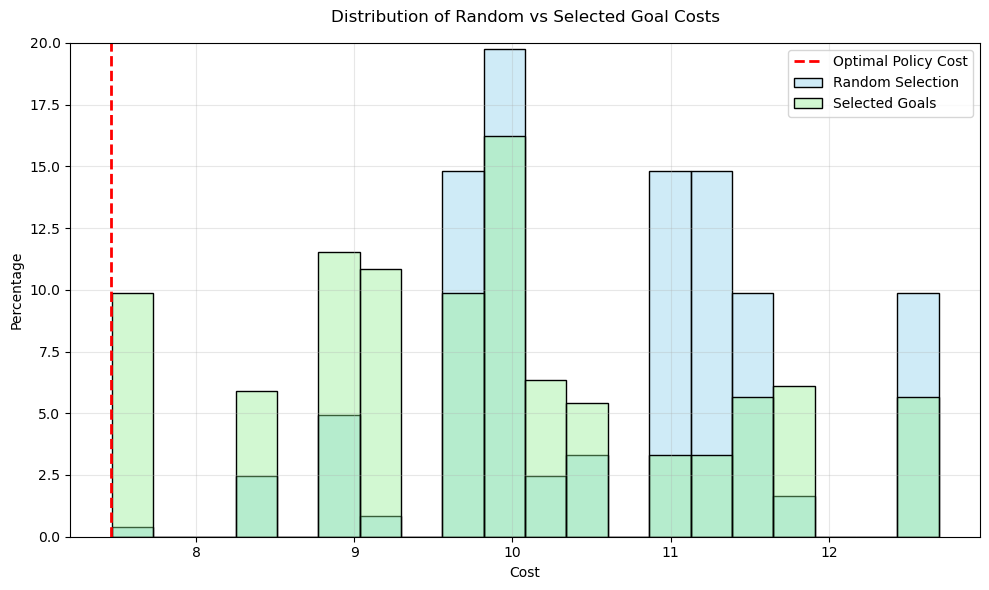

In [158]:
# Create the overlaid histograms
plt.figure(figsize=(10, 6))

# First histogram - Value function (theoretical costs)
sns.histplot(
    data=value_function, 
    x='value', 
    bins=20, 
    color='skyblue', 
    alpha=0.4,  # More transparent
    edgecolor='black',
    stat='percent',
    label='Random Selection'  # Add label for legend
)

# Second histogram - Selected goals (actual costs)
sns.histplot(
    data=selected_goals, 
    x='cost', 
    bins=20, 
    color='lightgreen', 
    alpha=0.4,  # More transparent
    edgecolor='black',
    stat='percent',
    label='Selected Goals'  # Add label for legend
)

# Add vertical line at 7.46
plt.axvline(x=7.46, color='red', linestyle='--', linewidth=2, label='Optimal Policy Cost')

# Customize the plot
plt.title('Distribution of Random vs Selected Goal Costs', fontsize=12, pad=15)
plt.xlabel('Cost', fontsize=10)
plt.ylabel('Percentage', fontsize=10)
plt.ylim(0,20)
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

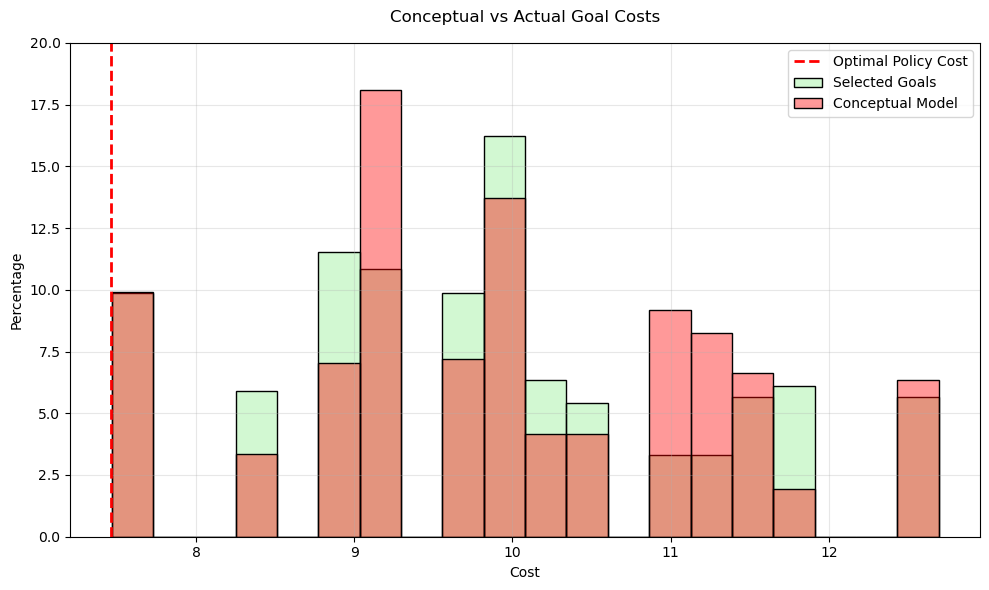

In [157]:
# Create the overlaid histograms
plt.figure(figsize=(10, 6))

# Second histogram - Selected goals (actual costs)
sns.histplot(
    data=selected_goals, 
    x='cost', 
    bins=20, 
    color='lightgreen', 
    alpha=0.4,  # More transparent
    edgecolor='black',
    stat='percent',
    label='Selected Goals'  # Add label for legend
)

costs = -1 * costs

sns.histplot(
    x=costs, 
    bins=20, 
    color='red', 
    alpha=0.4,  # More transparent
    edgecolor='black',
    stat='percent',
    label='Conceptual Model'  # Add label for legend
)

# Add vertical line at 7.46
plt.axvline(x=7.46, color='red', linestyle='--', linewidth=2, label='Optimal Policy Cost')

# Customize the plot
plt.title('Conceptual vs Actual Goal Costs', fontsize=12, pad=15)
plt.xlabel('Cost', fontsize=10)
plt.ylim(0, 20)
plt.ylabel('Percentage', fontsize=10)
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

Bootstrapping:   0%|          | 0/10000 [00:00<?, ?it/s]

Observed difference in means: -0.768
P-value: 0.0000


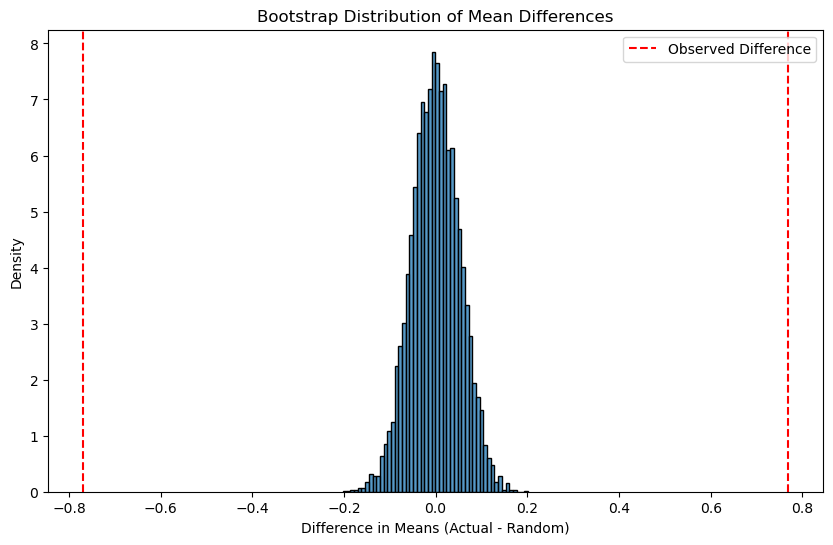

In [50]:
import numpy as np
from tqdm.notebook import tqdm

def bootstrap_test(actual_costs, random_costs, n_bootstraps=10000):
    """
    Perform a bootstrapping test to compare two distributions.
    
    Args:
        actual_costs: Array of costs from selected goals
        random_costs: Array of costs from random goals
        n_bootstraps: Number of bootstrap samples to generate
        
    Returns:
        p_value: The probability that the observed difference could occur by chance
        observed_diff: The observed difference in means
        bootstrap_diffs: Array of bootstrap differences
    """
    # Calculate observed difference in means
    observed_diff = np.mean(actual_costs) - np.mean(random_costs)
    
    # Combine the data
    combined = np.concatenate([actual_costs, random_costs])
    
    # Initialize array to store bootstrap differences
    bootstrap_diffs = np.zeros(n_bootstraps)
    
    # Perform bootstrapping
    for i in tqdm(range(n_bootstraps), desc="Bootstrapping"):
        # Resample with replacement
        resample = np.random.choice(combined, size=len(combined), replace=True)
        
        # Split into two groups of original sizes
        resample_actual = resample[:len(actual_costs)]
        resample_random = resample[len(actual_costs):]
        
        # Calculate difference in means
        bootstrap_diffs[i] = np.mean(resample_actual) - np.mean(resample_random)
    
    # Calculate p-value (two-tailed test)
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
    
    return p_value, observed_diff, bootstrap_diffs

# Extract the cost data from your DataFrames
actual_costs = selected_goals['cost'].values
random_costs = value_function['value'].values

# Run the bootstrap test
p_value, observed_diff, bootstrap_diffs = bootstrap_test(actual_costs, random_costs)

# Print results
print(f"Observed difference in means: {observed_diff:.3f}")
print(f"P-value: {p_value:.4f}")

# Create a visualization of the bootstrap distribution
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_diffs, bins=50, stat='density')
plt.axvline(x=observed_diff, color='red', linestyle='--', label='Observed Difference')
plt.axvline(x=-observed_diff, color='red', linestyle='--')
plt.title('Bootstrap Distribution of Mean Differences')
plt.xlabel('Difference in Means (Actual - Random)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Program Length

In [30]:
from rllib.shapeworld import State, Shape, ShapeWorld
import logging

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

def program_applies(program: str, state: State) -> bool:
    """Check if a program applies to a state."""
    try:
        # Remove quotes if present
        program = program.strip('"')
        
        # Handle conjunctions
        if program.startswith('and('):
            # Validate and format
            if not program.endswith(')'):
                logger.error(f"Invalid conjunction format (missing closing parenthesis): {program}")
                return False
                
            # Split into subprograms more carefully
            inner = program[4:-1]  # Remove 'and(' and ')'
            paren_count = 0
            split_point = -1
            
            # Find the correct comma to split on
            for i, char in enumerate(inner):
                if char == '(':
                    paren_count += 1
                elif char == ')':
                    paren_count -= 1
                elif char == ',' and paren_count == 0:
                    split_point = i
                    break
            
            if split_point == -1:
                logger.error(f"Invalid conjunction format (no main comma found): {program}")
                return False
                
            subprograms = [inner[:split_point].strip(), inner[split_point+1:].strip()]
            return program_applies(subprograms[0], state) and program_applies(subprograms[1], state)
        
        # Validate basic program format
        if not ('(' in program and program.endswith(')')):
            logger.error(f"Invalid program format: {program}")
            return False
            
        # Parse function and arguments more carefully
        try:
            func, rest = program.split('(', 1)
            if not rest.endswith(')'):
                logger.error(f"Invalid program format (missing closing parenthesis): {program}")
                return False
                
            # Split arguments with proper parentheses handling
            args_str = rest[:-1]  # Remove closing parenthesis
            args = []
            current_arg = ''
            paren_count = 0
            
            for char in args_str:
                if char == '(' and paren_count == 0:
                    current_arg += char
                    paren_count += 1
                elif char == ')' and paren_count == 1:
                    current_arg += char
                    paren_count -= 1
                elif char == ',' and paren_count == 0:
                    args.append(current_arg.strip())
                    current_arg = ''
                else:
                    current_arg += char
                    if char == '(':
                        paren_count += 1
                    elif char == ')':
                        paren_count -= 1
            
            if current_arg:
                args.append(current_arg.strip())
                
            if not args:
                logger.error(f"No arguments found in program: {program}")
                return False
                
        except ValueError as e:
            logger.error(f"Failed to parse program {program}: {str(e)}")
            return False
        
        # Get shapes from state for easier access
        shapes = [state.shape1, state.shape2, state.shape3]
        
        # Helper function to count matching features
        def count_matching_feature(feature: str) -> int:
            if feature in ['square', 'circle', 'triangle']:
                return sum(1 for shape in shapes if shape.sides == feature)
            elif feature in ['low', 'medium', 'high']:
                return sum(1 for shape in shapes if shape.shade == feature)
            elif feature in ['plain', 'stripes', 'dots']:
                return sum(1 for shape in shapes if shape.texture == feature)
            return 0
        
        # Helper function to get shapes at specified locations
        def get_shapes_at_locations(loc_str: str) -> list:
            locations = [int(x) for x in loc_str.strip('()').split(',')]
            return [shapes[i] for i in locations]
        
        # Helper function to check if shapes have same feature
        def have_same_feature(shape_list: list) -> bool:
            return (len(set(s.sides for s in shape_list)) == 1 and
                    len(set(s.shade for s in shape_list)) == 1 and
                    len(set(s.texture for s in shape_list)) == 1)
        
        # Helper function to check if shapes have unique features
        def have_unique_features(shape_list: list) -> bool:
            return (len(set(s.sides for s in shape_list)) == len(shape_list) and
                    len(set(s.shade for s in shape_list)) == len(shape_list) and
                    len(set(s.texture for s in shape_list)) == len(shape_list))
        
        # Handle different program types
        if func == 'one':
            if len(args) == 1:  # one(feature)
                return count_matching_feature(args[0]) == 1
            else:  # one(feature,location)
                target_shapes = get_shapes_at_locations(args[1])
                return any(count_matching_feature(args[0]) == 1 for shape in target_shapes)
            
        elif func == 'two':
            if len(args) == 1:  # two(feature) or two(relation)
                if args[0] in ['same', 'unique']:
                    # Check pairs of shapes
                    pairs = [(shapes[i], shapes[j]) 
                            for i in range(3) for j in range(i+1, 3)]
                    if args[0] == 'same':
                        # Count how many pairs have the same feature
                        matching_pairs = sum(1 for s1, s2 in pairs if have_same_feature([s1, s2]))
                        return matching_pairs == 2  # Exactly two pairs match
                    else:  # unique
                        # Count how many pairs have unique features
                        matching_pairs = sum(1 for s1, s2 in pairs if have_unique_features([s1, s2]))
                        return matching_pairs == 2  # Exactly two pairs match
                else:  # feature
                    return count_matching_feature(args[0]) == 2
                
            elif len(args) == 2:
                if args[0] in ['1', '2', '3']:  # two(num_features,relation)
                    num_features = int(args[0])
                    pairs = [(shapes[i], shapes[j]) 
                            for i in range(3) for j in range(i+1, 3)]
                    for s1, s2 in pairs:
                        matches = (
                            (s1.sides == s2.sides) +
                            (s1.shade == s2.shade) +
                            (s1.texture == s2.texture)
                        )
                        if matches == num_features:
                            return True
                    return False
                else:  # two(feature,location)
                    target_shapes = get_shapes_at_locations(args[1])
                    return all(count_matching_feature(args[0]) == 1 for shape in target_shapes)
        
        elif func == 'three':
            if len(args) == 1:
                if args[0] in ['same', 'unique']:
                    if args[0] == 'same':
                        return have_same_feature(shapes)
                    else:  # unique
                        return have_unique_features(shapes)
                else:  # feature
                    return count_matching_feature(args[0]) == 3
            elif len(args) == 2:  # three(num_features,relation)
                num_features = int(args[0])
                matches = (
                    (shapes[0].sides == shapes[1].sides == shapes[2].sides) +
                    (shapes[0].shade == shapes[1].shade == shapes[2].shade) +
                    (shapes[0].texture == shapes[1].texture == shapes[2].texture)
                )
                return matches == num_features
        
        return False

    except Exception as e:
        logger.error(f"Error processing program '{program}': {str(e)}")
        return False

    

In [31]:
productions = [
  ['S', ['and(S,S)', 'A']], # allow conjunctions
  ['A', ['one(B)', 'two(B)', 'three(B)', # location symmetry, fix one feature (location agnostic, compare feature)
         'two(E)', 'three(E)', # location symetry, feature symmetry (location agnostic, feature agnostic)
         'two(F,E)', 'three(F,E)', # location symmetry, multiple feature symetry (location agnostic, feature agnostic)
         'one(B,C)', 'two(B,D)', # feature in location, specify feature (location given, feature compare)
         'two(E,D)'# give location, feature symmetry (location given, feature agnostic)
         ]],
  ['B', ['square', 'circle', 'triangle', 'low', 'medium', 'high', 'plain', 'stripes', 'dots']], # features
  ['C', ['(0)', '(1)', '(2)']], # locations
  ['D', ['(0,1)', '(0,2)', '(1,2)']], # diad locations
  ['E', ['same','unique']], # relation,
  ['F', ['1','2','3']], # number of features to compare
]

def calculate_program_length(program: str, productions: list) -> int:
    """Calculate the length of a program based on primitive elements in production rules."""
    # First, create a set of all primitives from the production rules
    primitives = {
        'square', 'circle', 'triangle',  # shapes
        'low', 'medium', 'high',         # shades
        'plain', 'stripes', 'dots',      # textures
        'same', 'unique',                # relations
        '1', '2', '3',                   # numbers
        'one', 'two', 'three', 'and'     # functions
    }
    
    # Also count location specifications as primitives
    location_primitives = {'(0)', '(1)', '(2)', '(0,1)', '(0,2)', '(1,2)'}
    
    def tokenize(program: str) -> list:
        """Split program into tokens including functions and primitives."""
        # Remove quotes if present
        program = program.strip('"')
        tokens = []
        
        # Split on parentheses and commas while preserving location specifications
        current_token = ""
        paren_level = 0
        
        for i, char in enumerate(program):
            if char == '(':
                if current_token:
                    tokens.append(current_token)
                current_token = ""
                if i + 3 <= len(program) and program[i:i+3] in ['(0)', '(1)', '(2)']:
                    tokens.append(program[i:i+3])
                    i += 2
                elif i + 5 <= len(program) and program[i:i+5] in ['(0,1)', '(0,2)', '(1,2)']:
                    tokens.append(program[i:i+5])
                    i += 4
                paren_level += 1
            elif char == ')':
                if current_token:
                    tokens.append(current_token)
                current_token = ""
                paren_level -= 1
            elif char == ',' and paren_level == 1:
                if current_token:
                    tokens.append(current_token)
                current_token = ""
            else:
                current_token += char
        
        if current_token:
            tokens.append(current_token)
        
        return [t.strip() for t in tokens if t.strip()]
    
    # Get tokens and count primitives
    tokens = tokenize(program)
    length = sum(1 for token in tokens if token in primitives or token in location_primitives)
    
    #print(f"Debug - Program: {program}")
    #print(f"Debug - Tokens: {tokens}")
    #print(f"Debug - Primitives found: {[t for t in tokens if t in primitives or t in location_primitives]}")
    
    return length

# Test the function
example_programs = [
    'one(square)',              # should be 2 (one, square)
    'two(same)',               # should be 2 (two, same)
    'and(one(circle),two(low))',  # should be 5 (and, one, circle, two, low)
    'two(2,same)',             # should be 3 (two, 2, same)
    'three(unique)',           # should be 2 (three, unique)
    'one(square,(0))',         # should be 3 (one, square, (0))
]

print("Program lengths:")
for prog in example_programs:
    length = calculate_program_length(prog, productions)
    print(f"{prog}: {length}")

Program lengths:
one(square): 2
two(same): 2
and(one(circle),two(low)): 5
two(2,same): 3
three(unique): 2
one(square,(0)): 3


In [32]:
# Read in the list of programs
programs_df = pd.read_csv('../simulations/pcfg_programs.csv')
programs = programs_df['program'].tolist()
test_program = programs[22]
print(test_program)

test_state = State(
    shape1=Shape(sides='circle', shade='low', texture='stripes'),
    shape2=Shape(sides='square', shade='low', texture='plain'),
    shape3=Shape(sides='triangle', shade='medium', texture='dots')
)

program_applies(test_program, test_state)


three(low)


False

In [36]:
def extract_goals(selected_goals: pd.DataFrame) -> List[State]:
    """Extract goal states from the selected_goals dataframe."""
    goals = []
    for _, row in selected_goals.iterrows():
        goal = State(
            shape1=Shape(sides=row['shape_0_type'], shade=row['shape_0_shade'], texture=row['shape_0_texture']),
            shape2=Shape(sides=row['shape_1_type'], shade=row['shape_1_shade'], texture=row['shape_1_texture']),
            shape3=Shape(sides=row['shape_2_type'], shade=row['shape_2_shade'], texture=row['shape_2_texture'])
        )
        goals.append(goal)
    return np.array(goals)



In [37]:
def find_applicable_programs(goal: State, programs: List[str]) -> List[str]:
    """Find the applicable programs for a given goal."""
    applicable_programs = []
    for program in programs:
        if program_applies(program, goal):
            applicable_programs.append(program)
    return applicable_programs

test_state = State(
    shape1=Shape(sides='circle', shade='low', texture='dots'),
    shape2=Shape(sides='circle', shade='low', texture='dots'),
    shape3=Shape(sides='circle', shade='low', texture='dots')
)

find_applicable_programs(test_state, programs)

['three(same)',
 'three(3,same)',
 'two(3,unique)',
 'two(3,same)',
 'three(3,unique)',
 'three(low)',
 'three(circle)',
 'three(dots)',
 'and(three(same),three(same))',
 'and(three(same),three(3,unique))',
 'and(three(same),two(3,unique))',
 'and(three(same),two(3,same))',
 'and(three(same),three(3,same))',
 'and(three(3,unique),three(same))',
 'and(two(3,same),three(same))',
 'and(two(3,unique),three(same))',
 'and(three(3,same),three(same))',
 'and(three(circle),three(same))',
 'and(three(low),three(same))',
 'and(three(dots),three(same))',
 'and(three(same),three(dots))',
 'and(three(same),three(low))',
 'and(three(same),three(circle))',
 'and(three(3,same),three(3,unique))',
 'and(three(3,unique),two(3,same))',
 'and(three(3,unique),two(3,unique))',
 'and(three(3,unique),three(3,same))',
 'and(three(3,unique),three(3,unique))',
 'and(three(3,same),three(3,same))',
 'and(three(3,same),two(3,same))',
 'and(three(3,same),two(3,unique))',
 'and(two(3,unique),two(3,same))',
 'and(two(3

In [39]:
goals = extract_goals(selected_goals)

num_programs = []
min_length = []
max_length = []
avg_length = []

for goal in tqdm.tqdm(goals):
    applicable_programs = find_applicable_programs(goal, programs)
    num_programs.append(len(applicable_programs))
    min_length.append(min(calculate_program_length(p, productions) for p in applicable_programs))
    max_length.append(max(calculate_program_length(p, productions) for p in applicable_programs))
    avg_length.append(sum(calculate_program_length(p, productions) for p in applicable_programs) / len(applicable_programs))

goals_df = pd.DataFrame({
    'num_programs': num_programs,
    'min_length': min_length,
    'max_length': max_length,
    'avg_length': avg_length,
    'goals': goals
})

goals_df



100%|██████████| 425/425 [00:17<00:00, 24.40it/s]


,num_programs,min_length,max_length,avg_length,goals
0,1560,2,7,5.351923,"State(shape1=Shape(sides='triangle', shade='hi..."
1,552,2,7,4.748188,"State(shape1=Shape(sides='square', shade='high..."
2,756,2,7,5.072751,"State(shape1=Shape(sides='triangle', shade='me..."
3,552,2,7,4.748188,"State(shape1=Shape(sides='square', shade='high..."
4,1332,2,7,5.055556,"State(shape1=Shape(sides='triangle', shade='hi..."
...,...,...,...,...,...
420,272,2,7,4.404412,"State(shape1=Shape(sides='square', shade='medi..."
421,552,2,7,4.748188,"State(shape1=Shape(sides='square', shade='medi..."
422,272,2,7,4.404412,"State(shape1=Shape(sides='square', shade='high..."
423,272,2,7,4.404412,"State(shape1=Shape(sides='square', shade='medi..."


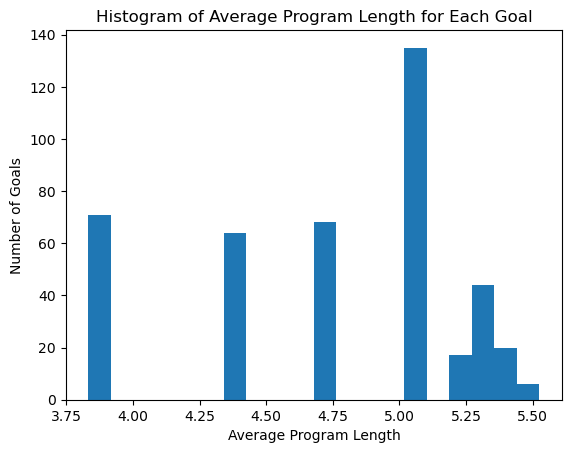

In [41]:
# Plot a histogram of the average program length for each goal
plt.hist(goals_df['avg_length'], bins=20)
plt.xlabel('Average Program Length')
plt.ylabel('Number of Goals')
plt.title('Histogram of Average Program Length for Each Goal')
plt.show()



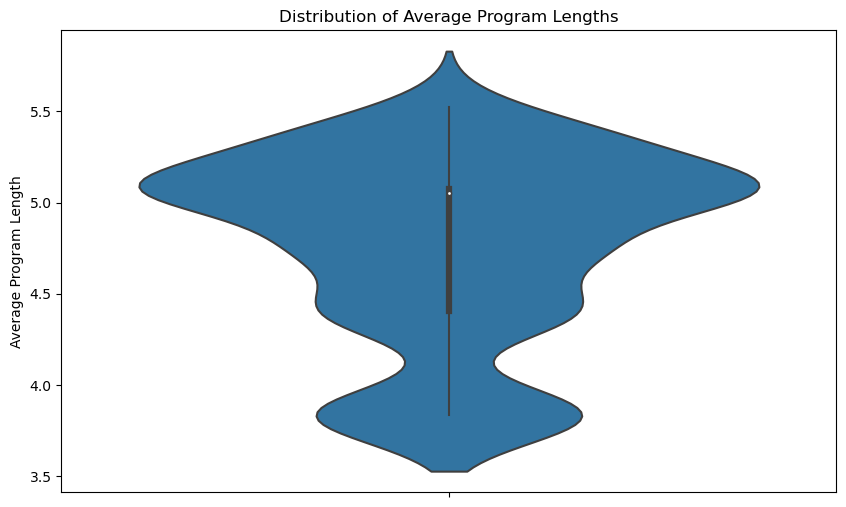

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(y=goals_df['avg_length'])
plt.ylabel('Average Program Length')
plt.title('Distribution of Average Program Lengths')
plt.show()

In [43]:
test_state = State(
    shape1=Shape(sides='circle', shade='medium', texture='dots'),
    shape2=Shape(sides='circle', shade='medium', texture='stripes'),
    shape3=Shape(sides='circle', shade='medium', texture='stripes')
)

find_applicable_programs(test_state, programs)

['three(2,unique)',
 'three(2,same)',
 'two(3,unique)',
 'two(3,same)',
 'two(2,unique)',
 'two(2,same)',
 'three(medium)',
 'two(stripes)',
 'three(circle)',
 'one(dots)',
 'two(dots,(0,1))',
 'two(dots,(0,2))',
 'two(dots,(1,2))',
 'one(dots,(0))',
 'one(dots,(1))',
 'one(dots,(2))',
 'and(three(2,same),two(3,same))',
 'and(three(2,same),three(2,unique))',
 'and(three(2,same),three(2,same))',
 'and(three(2,same),two(3,unique))',
 'and(three(2,same),two(2,unique))',
 'and(three(2,same),two(2,same))',
 'and(three(2,unique),two(2,same))',
 'and(three(2,unique),two(2,unique))',
 'and(three(2,unique),two(3,same))',
 'and(three(2,unique),two(3,unique))',
 'and(three(2,unique),three(2,unique))',
 'and(three(2,unique),three(2,same))',
 'and(two(2,same),three(2,unique))',
 'and(two(2,unique),two(2,same))',
 'and(two(2,unique),two(2,unique))',
 'and(two(2,unique),two(3,same))',
 'and(two(2,unique),two(3,unique))',
 'and(two(2,unique),three(2,same))',
 'and(two(2,unique),three(2,unique))',
 'an

# Feature Proportions

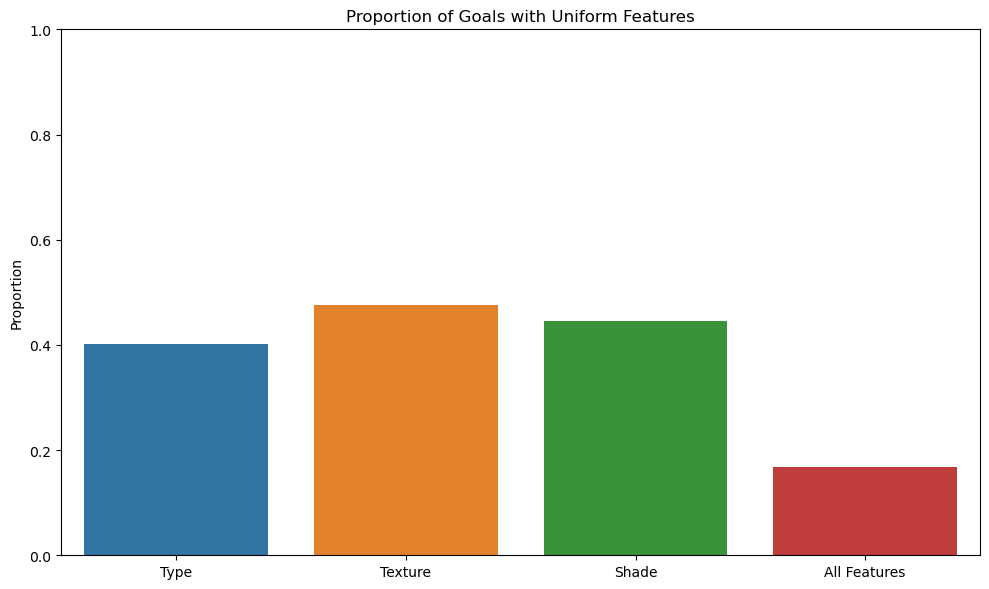

Type: 40.24%
Texture: 47.53%
Shade: 44.47%
All Features: 16.71%


In [ ]:
def analyze_uniformity_df(selected_goals):
    """
    Analyze uniformity of each feature separately.
    """
    # Check uniformity for each feature
    type_uniform = (selected_goals['shape_0_type'] == selected_goals['shape_1_type']) & \
                   (selected_goals['shape_1_type'] == selected_goals['shape_2_type'])
    
    texture_uniform = (selected_goals['shape_0_texture'] == selected_goals['shape_1_texture']) & \
                      (selected_goals['shape_1_texture'] == selected_goals['shape_2_texture'])
    
    shade_uniform = (selected_goals['shape_0_shade'] == selected_goals['shape_1_shade']) & \
                    (selected_goals['shape_1_shade'] == selected_goals['shape_2_shade'])
    
    # Calculate proportions
    results = {
        'Type': type_uniform.mean(),
        'Texture': texture_uniform.mean(),
        'Shade': shade_uniform.mean(),
        'All Features': (type_uniform & texture_uniform & shade_uniform).mean()
    }
    
    return results

# Run the analysis
uniformity_results = analyze_uniformity_df(selected_goals)

# Print the results
for feature, proportion in uniformity_results.items():
    print(f"{feature}: {proportion:.2%}")

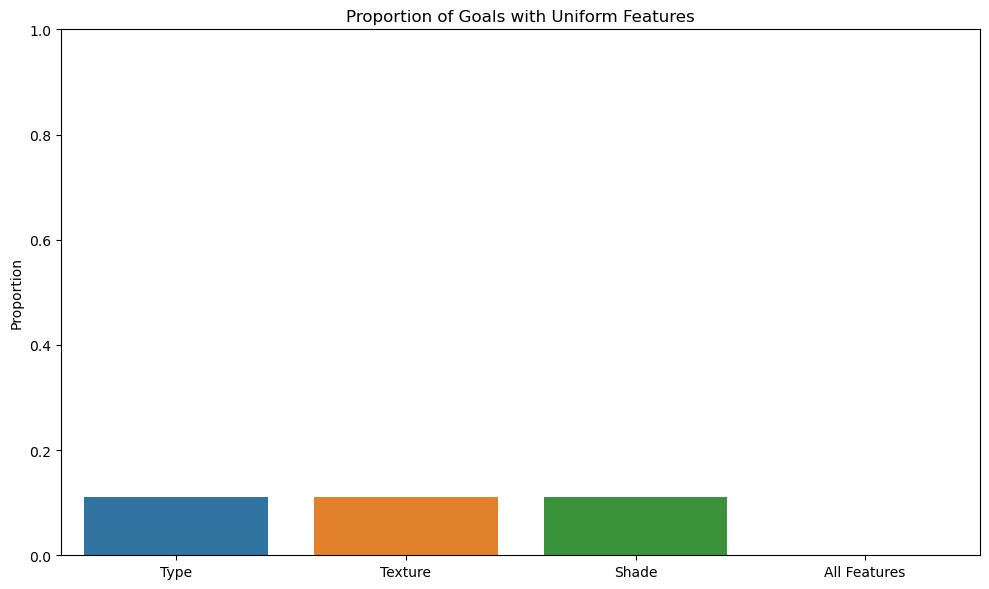

Type: 11.11%
Texture: 11.11%
Shade: 11.11%
All Features: 0.14%


In [62]:
# Read in the values for the goal pursuit cost
value_function = pd.read_csv('../simulations/value-functions/goal_value_function_mean.csv')

# Remove summary rows from value function
value_function = value_function[value_function['shape1_sides'] != 'SUMMARY']

def analyze_uniformity(selected_goals):
    """
    Analyze uniformity of each feature separately.
    """
    # Check uniformity for each feature
    type_uniform = (selected_goals['shape1_sides'] == selected_goals['shape2_sides']) & \
                   (selected_goals['shape2_sides'] == selected_goals['shape3_sides'])
    
    texture_uniform = (selected_goals['shape1_texture'] == selected_goals['shape2_texture']) & \
                      (selected_goals['shape2_texture'] == selected_goals['shape3_texture'])
    
    shade_uniform = (selected_goals['shape1_shade'] == selected_goals['shape2_shade']) & \
                    (selected_goals['shape2_shade'] == selected_goals['shape3_shade'])
    
    
    # Calculate proportions
    results = {
        'Type': type_uniform.mean(),
        'Texture': texture_uniform.mean(),
        'Shade': shade_uniform.mean(),
        'All Features': (type_uniform & texture_uniform & shade_uniform).mean()
    }
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(results.keys()), y=list(results.values()))
    plt.title('Proportion of Goals with Uniform Features')
    plt.ylabel('Proportion')
    plt.xticks(rotation=0)
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()
    
    return results

# Run the analysis
uniformity_results = analyze_uniformity(value_function)

# Print the results
for feature, proportion in uniformity_results.items():
    print(f"{feature}: {proportion:.2%}")

In [168]:
def bootstrap_proportion(data, n_bootstraps=1000):
    """
    Calculate bootstrapped confidence intervals for a proportion.
    """
    proportions = []
    for _ in tqdm(range(n_bootstraps), desc="Bootstrapping"):
        # Resample with replacement
        resample = np.random.choice(data, size=len(data), replace=True)
        # Calculate proportion for this bootstrap sample
        proportions.append(resample.mean())
    
    # Calculate 95% confidence interval
    lower = np.percentile(proportions, 2.5)
    upper = np.percentile(proportions, 97.5)
    return lower, upper

def analyze_uniformity_with_ci(selected_goals, n_bootstraps=1000):
    """
    Analyze uniformity of each feature with confidence intervals.
    """
    # Check uniformity for each feature
    type_uniform = (selected_goals['shape_0_type'] == selected_goals['shape_1_type']) & \
                   (selected_goals['shape_1_type'] == selected_goals['shape_2_type'])
    
    texture_uniform = (selected_goals['shape_0_texture'] == selected_goals['shape_1_texture']) & \
                      (selected_goals['shape_1_texture'] == selected_goals['shape_2_texture'])
    
    shade_uniform = (selected_goals['shape_0_shade'] == selected_goals['shape_1_shade']) & \
                    (selected_goals['shape_1_shade'] == selected_goals['shape_2_shade'])
    
    all_uniform = type_uniform & texture_uniform & shade_uniform
    
    # Calculate proportions and confidence intervals
    results = {
        'Type': {
            'proportion': type_uniform.mean(),
            'ci': bootstrap_proportion(type_uniform, n_bootstraps)
        },
        'Texture': {
            'proportion': texture_uniform.mean(),
            'ci': bootstrap_proportion(texture_uniform, n_bootstraps)
        },
        'Shade': {
            'proportion': shade_uniform.mean(),
            'ci': bootstrap_proportion(shade_uniform, n_bootstraps)
        },
        'All Features': {
            'proportion': all_uniform.mean(),
            'ci': bootstrap_proportion(all_uniform, n_bootstraps)
        }
    }
    
    # Create visualization with error bars
    plt.figure(figsize=(10, 6))
    
    # Extract data for plotting
    features = list(results.keys())
    proportions = [results[f]['proportion'] for f in features]
    ci_lower = [results[f]['ci'][0] for f in features]
    ci_upper = [results[f]['ci'][1] for f in features]
    errors = [proportions[i] - ci_lower[i] for i in range(len(proportions))]
    
    # Create bar plot with error bars
    bars = sns.barplot(features, proportions, yerr=errors, capsize=5)
    
    # Add error bars
    plt.errorbar(features, proportions, yerr=errors, fmt='none', 
                 ecolor='black', capsize=5)
    
    plt.title('Proportion of Goals with Uniform Features (95% CI)')
    plt.ylabel('Proportion')
    plt.ylim(0,1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print the results with confidence intervals
    for feature, data in results.items():
        print(f"{feature}: {data['proportion']:.2%} (95% CI: {data['ci'][0]:.2%} - {data['ci'][1]:.2%})")
    
    return results

# Run the analysis
uniformity_results = analyze_uniformity_with_ci(selected_goals)

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

TypeError: barplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Figure size 1000x600 with 0 Axes>

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

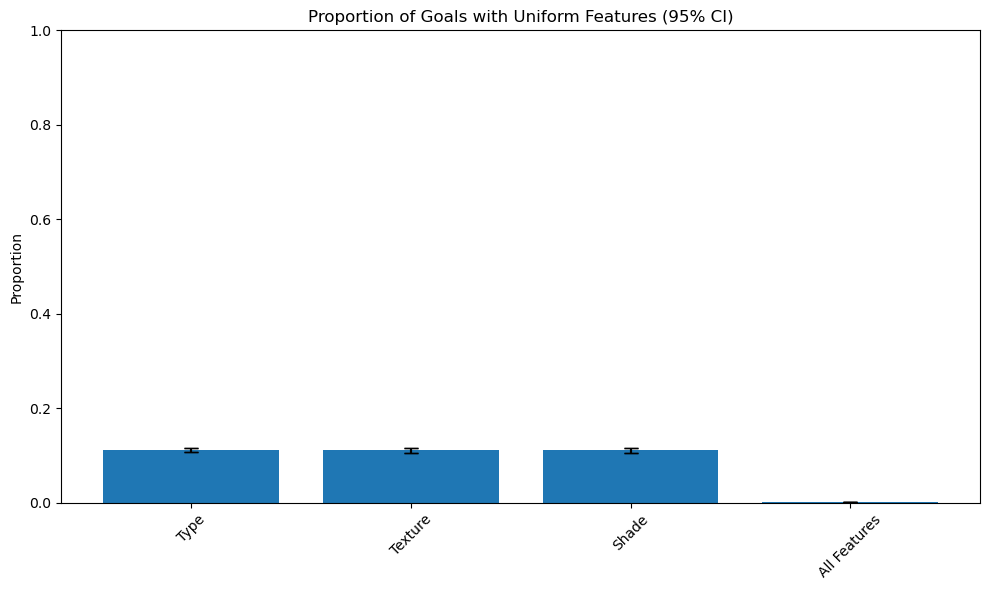

Type: 11.11% (95% CI: 10.67% - 11.58%)
Texture: 11.11% (95% CI: 10.64% - 11.51%)
Shade: 11.11% (95% CI: 10.65% - 11.55%)
All Features: 0.14% (95% CI: 0.09% - 0.19%)


In [66]:
def analyze_uniformity_with_ci(selected_goals, n_bootstraps=1000):
    """
    Analyze uniformity of each feature with confidence intervals.
    """
    # Check uniformity for each feature
    type_uniform = (selected_goals['shape1_sides'] == selected_goals['shape2_sides']) & \
                   (selected_goals['shape2_sides'] == selected_goals['shape3_sides'])
    
    texture_uniform = (selected_goals['shape1_texture'] == selected_goals['shape2_texture']) & \
                      (selected_goals['shape2_texture'] == selected_goals['shape3_texture'])
    
    shade_uniform = (selected_goals['shape1_shade'] == selected_goals['shape2_shade']) & \
                    (selected_goals['shape2_shade'] == selected_goals['shape3_shade'])
    
    all_uniform = type_uniform & texture_uniform & shade_uniform
    
    # Calculate proportions and confidence intervals
    results = {
        'Type': {
            'proportion': type_uniform.mean(),
            'ci': bootstrap_proportion(type_uniform, n_bootstraps)
        },
        'Texture': {
            'proportion': texture_uniform.mean(),
            'ci': bootstrap_proportion(texture_uniform, n_bootstraps)
        },
        'Shade': {
            'proportion': shade_uniform.mean(),
            'ci': bootstrap_proportion(shade_uniform, n_bootstraps)
        },
        'All Features': {
            'proportion': all_uniform.mean(),
            'ci': bootstrap_proportion(all_uniform, n_bootstraps)
        }
    }
    
    # Create visualization with error bars
    plt.figure(figsize=(10, 6))
    
    # Extract data for plotting
    features = list(results.keys())
    proportions = [results[f]['proportion'] for f in features]
    ci_lower = [results[f]['ci'][0] for f in features]
    ci_upper = [results[f]['ci'][1] for f in features]
    errors = [proportions[i] - ci_lower[i] for i in range(len(proportions))]
    
    # Create bar plot with error bars
    bars = plt.bar(features, proportions, yerr=errors, capsize=5)
    
    # Add error bars
    plt.errorbar(features, proportions, yerr=errors, fmt='none', 
                 ecolor='black', capsize=5)
    
    plt.title('Proportion of Goals with Uniform Features (95% CI)')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()
    
    # Print the results with confidence intervals
    for feature, data in results.items():
        print(f"{feature}: {data['proportion']:.2%} (95% CI: {data['ci'][0]:.2%} - {data['ci'][1]:.2%})")
    
    return results

uniformity_results = analyze_uniformity_with_ci(value_function)

# Posterior Predictive Checks: Conceptual

In [169]:
from rllib.shapeworld import State, Action, ShapeWorld, GoalWorld, Shape
from rllib.mdp import MDPPolicy, MarkovDecisionProcess
from typing import Sequence, Hashable, TypeVar, Generic
from random import Random
from scipy.optimize import minimize
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

S = TypeVar('S', bound=Hashable)  # Generic State type
A = TypeVar('A', bound=Hashable)  # Generic Action type

class GoalSelectionPolicy(Generic[S, A]):
    def __init__(self, mdp: MarkovDecisionProcess[S, A]):
        '''Initialize the policy with the MDP.'''
        self.mdp = mdp
        self.state_space = mdp.state_space

    def sample_action(self, s : S, rng : Random) -> tuple[A, float]:
        '''Uses some policy to select which goal to select.'''
        raise NotImplementedError
    
    def calc_log_lik(self, states : Sequence[S]) -> np.ndarray:
        '''Calculate the log likelihood of selecting a particular state.'''
        raise NotImplementedError
    
    def reset(self):
        raise NotImplementedError

class ConceptualGoalSelectionPolicy(GoalSelectionPolicy[S, A]):
    def __init__(self, mdp: MarkovDecisionProcess[S, A], pcfg_probs: pd.DataFrame):
        super().__init__(mdp)
        self.num_params = 1
        self.pcfg_probs = pcfg_probs
        self.beta = 1.4
        
        # Pre-compute numpy array of log probabilities
        self.log_probs = self.pcfg_probs['log_probability'].values
        
        # Pre-compute state objects and store as numpy array
        self.state_cache = np.array([
            State(
                shape1=Shape(sides=row['shape1_sides'], 
                           shade=row['shape1_shade'], 
                           texture=row['shape1_texture']),
                shape2=Shape(sides=row['shape2_sides'], 
                           shade=row['shape2_shade'], 
                           texture=row['shape2_texture']),
                shape3=Shape(sides=row['shape3_sides'], 
                           shade=row['shape3_shade'], 
                           texture=row['shape3_texture'])
            )
            for _, row in pcfg_probs.iterrows()
        ])
        
        # Cache for softmax probabilities
        self._cached_beta = None
        self._cached_probs = None
        
        # For faster random sampling
        self._cached_cumsum = None
    
    def _compute_probs(self, beta: float) -> np.ndarray:
        '''Compute softmax probabilities and cumulative sum for fast sampling.'''
        log_probs_shifted = beta * (self.log_probs - np.max(self.log_probs))
        exp_values = np.exp(log_probs_shifted)
        probs = exp_values / np.sum(exp_values)
        return probs, np.cumsum(probs)
    
    def sample_action(self, s: S, rng: Random, beta: float = None) -> A:
        '''Sample an action using softmax over PCFG log probabilities.'''
        if beta is None:
            beta = self.beta
            
        # Update probability cache if beta changed
        if beta != self._cached_beta:
            self._cached_probs, self._cached_cumsum = self._compute_probs(beta)
            self._cached_beta = beta
        
        # Fast random sampling using cumulative sum
        r = rng.random()
        chosen_idx = np.searchsorted(self._cached_cumsum, r)
        
        # Return pre-computed state
        return self.state_cache[chosen_idx]
    
    def _state_to_key(self, state: State) -> tuple:
        '''Convert a state object to a tuple of features for DataFrame lookup.'''
        
        return (
            state.shape1.sides, state.shape1.shade, state.shape1.texture,
            state.shape2.sides, state.shape2.shade, state.shape2.texture,
            state.shape3.sides, state.shape3.shade, state.shape3.texture
        )
    
    def neg_log_lik(self, beta: float, states: Sequence[S]) -> np.ndarray:
        '''Calculate the log likelihood of selecting an array of states.'''
        
        if beta is None:
            beta = self.beta

        # Update probability cache if beta changed
        if beta != self._cached_beta:
            self._cached_probs, self._cached_cumsum = self._compute_probs(beta)
            self._cached_beta = beta

        # Create lookup dictionary if it doesn't exist
        if not hasattr(self, '_state_to_idx'):
            self._state_to_idx = {
                tuple(row[['shape1_sides', 'shape1_shade', 'shape1_texture',
                        'shape2_sides', 'shape2_shade', 'shape2_texture',
                        'shape3_sides', 'shape3_shade', 'shape3_texture']]): i 
                for i, row in self.pcfg_probs.iterrows()
            }

        # Convert states to indices
        state_keys = [self._state_to_key(s) for s in states]
        indices = [self._state_to_idx[k] for k in state_keys]
        
        # Get log probabilities using indices
        log_probs = self.log_probs[indices]

        return -log_probs
    
    def sum_nll(self, beta: float, states: Sequence[S]) -> float:
        '''Sum the negative log likelihood of selecting an array of states.'''
        return np.sum(self.neg_log_lik(beta, states))
    
    def sum_nll_with_prior(self, beta: float, states: Sequence[S]) -> float:
        '''Sum the negative log likelihood plus the negative log prior (for MAP estimation).'''
        # Get negative log likelihood
        nll = self.sum_nll(beta, states)
        
        # Add negative log prior (gamma distribution)
        alpha = 5.0  # shape parameter (higher values push the mode higher)
        theta = 1.0  # scale parameter (higher values spread the distribution out)
        
        # Negative log of gamma pdf (dropping constant terms)
        neg_log_prior = -((alpha - 1) * np.log(beta)) + (beta / theta)
        
        return nll + neg_log_prior
    
    def max_posterior_estimate(self, states: Sequence[S]) -> tuple[float, float]:
        '''Use MAP to estimate the beta parameter using scipy.optimize.minimize.'''
        # We will minimize 5 times, and will take the best of those 5 starts
        initial_conds = np.random.uniform(low=1, high=10, size=5)
        bounds = [(0.001, None)]  # The bounds for inverse temperature are (0, inf)
        best_result = None
        best_nlp = np.inf  # negative log posterior
        
        # Minimize for each of the generated initial conditions
        for initial_cond in initial_conds:
            result = minimize(
                self.sum_nll_with_prior,  # Find parameter that minimizes neg log posterior
                args=(states,),
                x0=[initial_cond],
                bounds=bounds,
                method='L-BFGS-B'
            )
            
            # Take the best minimization so far
            if result.success and result.fun < best_nlp:
                best_result = result
                best_nlp = result.fun
                
        if best_result is None:
            raise RuntimeError("Optimization failed from all starting points")
            
        self.beta = best_result.x[0]
        self._cached_beta = best_result.x[0]
        self._cached_probs, self._cached_cumsum = self._compute_probs(best_result.x[0])
        return best_result.x[0], best_result.fun
    
    def calc_BIC(self, states: Sequence[S]) -> float:
        '''Calculate the BIC for the model with MAP estimate of beta'''
        # Note: We still use the likelihood term (not posterior) for BIC
        beta, nlp = self.max_posterior_estimate(states)
        nll = self.sum_nll(beta, states)  # Get just the likelihood term
        return 2 * nll + self.num_params * np.log(len(states))

    def reset(self):
        self._cached_beta = None
        self._cached_probs = None
        self._cached_cumsum = None

class GoalSimulationResult:
    def __init__(self, goals : np.ndarray):
        self.goals = goals

def run_strategy(
    *,
    policy : GoalSelectionPolicy[S, A],
    n_trials : int,
    n_episodes : int,
    seed : int
) -> GoalSimulationResult:
    # Set the random seed
    rng = random.Random(seed)
    np.random.seed(rng.randint(0, 2**32 - 1))

    # Initialize arrays to store State choices for each episode
    goals = np.zeros((n_episodes, n_trials), dtype=object)

    # Run n_episodes episodes
    for ep in range(n_episodes):
        policy.reset()
        for step in range(n_trials):
            a = policy.sample_action(rng=rng, s=None)
            goals[ep, step] = a

    return GoalSimulationResult(goals)

In [170]:
# Choose an arbitrary goal and discount rate
goal = State(shape1=Shape(sides='circle', shade='low', texture='plain'),
             shape2=Shape(sides='square', shade='medium', texture='stripes'),
             shape3=Shape(sides='triangle', shade='high', texture='dots'))
shape_world = ShapeWorld(goal=goal, discount_rate=0.99)

# Set the number of episodes and trials
n_episodes = 10000
n_trials = 20

# Create the agents
pcfg_probs = pd.read_csv('../simulations/pcfg_probabilities.csv')
conceptual_agent = ConceptualGoalSelectionPolicy(shape_world, pcfg_probs)

# Simulate episodes using the conceptual agent as the true model
selection = run_strategy(policy=conceptual_agent, 
                        n_trials=n_trials, 
                        n_episodes=n_episodes, 
                        seed=42)

In [186]:
# extract fit betas to subjects to simulate appropriate data for the given models
betas = np.unique(selected_goals['conceptual_beta'].values)
goals_sim = []

# Choose an arbitrary goal and discount rate
goal = State(shape1=Shape(sides='circle', shade='low', texture='plain'),
             shape2=Shape(sides='square', shade='medium', texture='stripes'),
             shape3=Shape(sides='triangle', shade='high', texture='dots'))
shape_world = ShapeWorld(goal=goal, discount_rate=0.99)

for beta in tqdm(betas):
    conceptual_agent = ConceptualGoalSelectionPolicy(shape_world, pcfg_probs)
    conceptual_agent.beta = beta
    selection = run_strategy(policy=conceptual_agent, 
                            n_trials=200, 
                            n_episodes=1 , 
                            seed=42)
    goals_sim.append(selection.goals.flatten())

goals_sim = np.array(goals_sim)

100%|██████████| 20/20 [00:08<00:00,  2.36it/s]


In [244]:
selected_goals_states

[State(shape1=Shape(sides='triangle', shade='high', texture='dots'), shape2=Shape(sides='circle', shade='high', texture='plain'), shape3=Shape(sides='circle', shade='low', texture='stripes')),
 State(shape1=Shape(sides='square', shade='high', texture='plain'), shape2=Shape(sides='circle', shade='high', texture='stripes'), shape3=Shape(sides='circle', shade='high', texture='plain')),
 State(shape1=Shape(sides='triangle', shade='medium', texture='dots'), shape2=Shape(sides='triangle', shade='medium', texture='stripes'), shape3=Shape(sides='triangle', shade='medium', texture='plain')),
 State(shape1=Shape(sides='square', shade='high', texture='plain'), shape2=Shape(sides='square', shade='high', texture='stripes'), shape3=Shape(sides='circle', shade='high', texture='stripes')),
 State(shape1=Shape(sides='triangle', shade='high', texture='dots'), shape2=Shape(sides='triangle', shade='high', texture='stripes'), shape3=Shape(sides='triangle', shade='medium', texture='plain')),
 State(shape1=S

/var/folders/qr/gb70fn114p97s4wfdyrjqlv40000gp/T/ipykernel_69987/3884208623.py:103: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


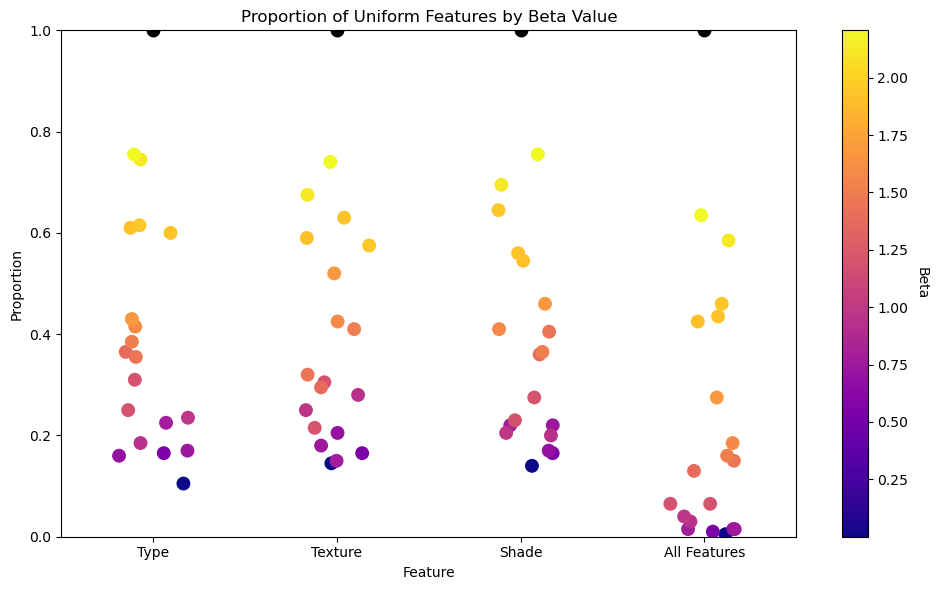

In [310]:
def analyze_uniformity_states(goal_states):
    """
    Analyze uniformity of each feature separately for a list of State objects.
    
    Args:
        goal_states: List of State objects from shapeworld
        
    Returns:
        Dictionary with proportions of uniform features
    """
    # Initialize counters
    type_uniform = 0
    texture_uniform = 0
    shade_uniform = 0
    all_uniform = 0
    total_goals = len(goal_states)
    
    # Check each state
    for state in goal_states:
        # Get shapes from state
        shapes = [state.shape1, state.shape2, state.shape3]
        
        # Check if all shapes have same type
        if all(s.sides == shapes[0].sides for s in shapes):
            type_uniform += 1
            
        # Check if all shapes have same texture
        if all(s.texture == shapes[0].texture for s in shapes):
            texture_uniform += 1
            
        # Check if all shapes have same shade
        if all(s.shade == shapes[0].shade for s in shapes):
            shade_uniform += 1
            
        # Check if all features are uniform
        if (all(s.sides == shapes[0].sides for s in shapes) and
            all(s.texture == shapes[0].texture for s in shapes) and
            all(s.shade == shapes[0].shade for s in shapes)):
            all_uniform += 1
    
    # Calculate proportions
    results = {
        'Type': type_uniform / total_goals,
        'Texture': texture_uniform / total_goals,
        'Shade': shade_uniform / total_goals,
        'All Features': all_uniform / total_goals
    }
    
    return results

# for each subject, calculate the proportion of goals with uniform features
results = []

for i in range(len(goals_sim)):
    results.append(analyze_uniformity_states(goals_sim[i]))

# First create the DataFrame with your results and betas
ppc_df_simresults = pd.DataFrame(results)
ppc_df_simresults['beta'] = betas

# Melt while keeping the beta column as an identifier
ppc_df_simresults = ppc_df_simresults.melt(
    id_vars=['beta'],  # Keep beta column
    var_name='Feature', 
    value_name='Proportion'
)

# Split the data into regular and high beta values
regular_betas_sim = ppc_df_simresults[ppc_df_simresults['beta'] < 45]
high_betas_sim = ppc_df_simresults[ppc_df_simresults['beta'] >= 45]

plt.figure(figsize=(10, 6))

# Plot regular beta values with color gradient
sns.stripplot(
    data=regular_betas_sim,
    x='Feature',
    y='Proportion',
    hue='beta',
    jitter=0.2,
    alpha=1,
    palette='plasma',
    s=10,
    legend=False  # Disable the default legend
)

# Add high beta values as black dots
sns.stripplot(
    data=high_betas_sim,
    x='Feature',
    y='Proportion',
    color='black',
    marker='o',
    s=10,
    # label='β ≥ 45',
    legend='brief'
)

# Create a continuous colorbar
norm = plt.Normalize(regular_betas_sim['beta'].min(), regular_betas_sim['beta'].max())
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Beta', rotation=270, labelpad=15)

plt.ylim(0, 1)
plt.title('Proportion of Uniform Features by Beta Value')
plt.tight_layout()
plt.show()


/var/folders/qr/gb70fn114p97s4wfdyrjqlv40000gp/T/ipykernel_69987/3964294426.py:80: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


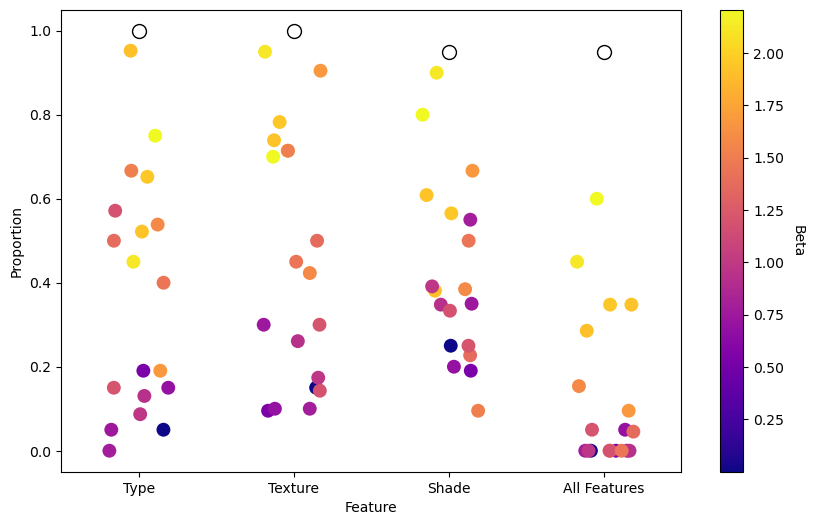

In [309]:
def analyze_uniformity_df(selected_goals):
    """
    Analyze uniformity of each feature separately.
    """
    # Check uniformity for each feature
    type_uniform = (selected_goals['shape_0_type'] == selected_goals['shape_1_type']) & \
                   (selected_goals['shape_1_type'] == selected_goals['shape_2_type'])
    
    texture_uniform = (selected_goals['shape_0_texture'] == selected_goals['shape_1_texture']) & \
                      (selected_goals['shape_1_texture'] == selected_goals['shape_2_texture'])
    
    shade_uniform = (selected_goals['shape_0_shade'] == selected_goals['shape_1_shade']) & \
                    (selected_goals['shape_1_shade'] == selected_goals['shape_2_shade'])
    
    # Calculate proportions
    results = {
        'Type': type_uniform.mean(),
        'Texture': texture_uniform.mean(),
        'Shade': shade_uniform.mean(),
        'All Features': (type_uniform & texture_uniform & shade_uniform).mean(),
        'participant_id': selected_goals['participant_id'].iloc[0],
        'beta': selected_goals['conceptual_beta'].iloc[0]
    }
    
    return results

participant_uniformity_results = []

for participant_id, group in selected_goals.groupby('participant_id'):
    uniformity_results = analyze_uniformity_df(group)
    participant_uniformity_results.append(uniformity_results)

participant_uniformity_results_df = pd.DataFrame(participant_uniformity_results)

# melt the dataframe
participant_uniformity_results_df = participant_uniformity_results_df.melt(
    id_vars=['participant_id', 'beta'],
    var_name='Feature',
    value_name='Proportion'
)

# split the dataframe into regular and high beta values
regular_betas_real = participant_uniformity_results_df[participant_uniformity_results_df['beta'] < 45]
high_betas_real = participant_uniformity_results_df[participant_uniformity_results_df['beta'] >= 45]

# Plot the results
plt.figure(figsize=(10, 6))

# Plot regular beta values with color gradient
sns.stripplot(
    data=regular_betas_real,
    x='Feature',
    y='Proportion',
    hue='beta',
    jitter=0.2,
    alpha=1,
    palette='plasma',
    s=10,
    legend=False  # Disable the default legend
)

# Add high beta values as black dots
sns.stripplot(
    data=high_betas_real,
    x='Feature',
    y='Proportion',
    color='white',
    marker='o',
    s=10,
    edgecolor='black',
    linewidth=1,
    # label='β ≥ 45',
    legend='brief'
)

# Create a continuous colorbar
norm = plt.Normalize(regular_betas_real['beta'].min(), regular_betas_real['beta'].max())
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Beta', rotation=270, labelpad=15)



/var/folders/qr/gb70fn114p97s4wfdyrjqlv40000gp/T/ipykernel_69987/2283791988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regular_betas_sim['Source'] = 'Simulated'
/var/folders/qr/gb70fn114p97s4wfdyrjqlv40000gp/T/ipykernel_69987/2283791988.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regular_betas_real['Source'] = 'Real'
/opt/anaconda3/envs/goals-concepts/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, 

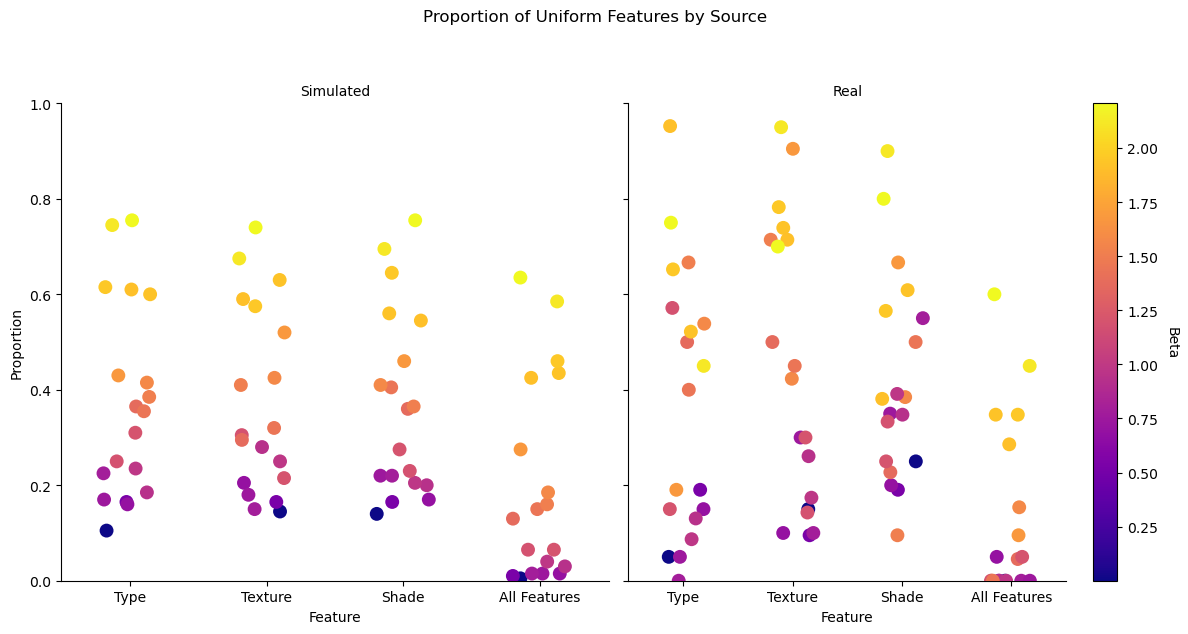

In [312]:
# Combine all the data
regular_betas_sim['Source'] = 'Simulated'
regular_betas_real['Source'] = 'Real'

combined_data = pd.concat([
    pd.concat([regular_betas_sim, high_betas_sim]),
    pd.concat([regular_betas_real, high_betas_real])
])

# Create the faceted plot
g = sns.FacetGrid(
    combined_data,
    col='Source',
    height=6,
    aspect=1,
    sharey=True
)

# Define the plotting function
def plot_strip(data, **kwargs):
    # Regular beta points
    regular = data[data['beta'] < 45]
    high = data[data['beta'] >= 45]
    
    # Plot regular beta values
    sns.stripplot(
        data=regular,
        x='Feature',
        y='Proportion',
        hue='beta',
        jitter=0.2,
        alpha=1,
        palette='plasma',
        s=10,
        legend=False
    )
    
    # Plot high beta values
    sns.stripplot(
        data=high,
        x='Feature',
        y='Proportion',
        color='white',
        edgecolor='black',
        linewidth=1,
        marker='o',
        s=10,
        legend=False
    )

# Apply the plotting function
g.map_dataframe(plot_strip)

# Add a colorbar
norm = plt.Normalize(regular_betas_sim['beta'].min(), regular_betas_sim['beta'].max())
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Beta', rotation=270, labelpad=15)

# Customize the plot
g.set_axis_labels('Feature', 'Proportion')
g.set_titles('{col_name}')
g.fig.suptitle('Proportion of Uniform Features by Source', y=1.05)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [306]:
combined_data.head(50)

,participant_id,beta,Feature,Proportion,Source
0,0q05ghjgecokfzbbdwxc7134,0.528656,Type,0.190476,Simulated
1,3gqicanjopq8enwcvi41tl45,0.000100,Type,0.050000,Simulated
2,4hbxerc9g325ivvae6m3t3yz,0.694987,Type,0.150000,Simulated
3,5z304yl2q2hzhr2mq4fhcpa5,1.370984,Type,0.500000,Simulated
4,640wotijlh33wcs613k9wcm1,2.118773,Type,0.450000,Simulated
5,b4ag56mldh0dsv5m5o4tp2jp,0.786914,Type,0.000000,Simulated
6,dsa8sulv7yis7xga9nyddwn3,1.928228,Type,0.521739,Simulated
7,hnbc1nhhwyd6f1x09lp4r2yy,0.748987,Type,0.050000,Simulated
8,ld0av55phjvohmllcrvpdbxv,1.678907,Type,0.190476,Simulated
9,m45j2qk7ziuljeeffbj84lpx,0.931366,Type,0.130435,Simulated


In [297]:
plt.figure(figsize=(10, 6))
combined_data

# Plot regular beta values
regular_data = combined_data[combined_data['beta'] < 45]
sns.scatterplot(
    data=regular_data[regular_data['Feature'] == 'Type'],
    x='Feature',
    y='Proportion',
    hue='Source',
    dodge=True,
    jitter=0.2,
    alpha=0.6,
    size=8,
    palette=['#ff7f0e', '#1f77b4']
)

# # Plot high beta values with different markers
# high_data = combined_data[combined_data['beta'] >= 45]
# sns.stripplot(
#     data=high_data,
#     x='Feature',
#     y='Proportion',
#     hue='Source',
#     dodge=True,
#     jitter=0.2,
#     alpha=0.6,
#     size=8,
#     marker='s',  # Square marker for high beta values
#     palette=['#ff7f0e', '#1f77b4']
# )

# plt.ylim(0, 1)
# plt.title('Comparison of Simulated vs Real Proportion of Uniform Features')
# plt.legend(title='Source')
# plt.tight_layout()
# plt.show()

,participant_id,beta,Feature,Proportion,Source
0,0q05ghjgecokfzbbdwxc7134,0.528656,Type,0.190476,Simulated
1,3gqicanjopq8enwcvi41tl45,0.000100,Type,0.050000,Simulated
2,4hbxerc9g325ivvae6m3t3yz,0.694987,Type,0.150000,Simulated
3,5z304yl2q2hzhr2mq4fhcpa5,1.370984,Type,0.500000,Simulated
4,640wotijlh33wcs613k9wcm1,2.118773,Type,0.450000,Simulated
...,...,...,...,...,...
79,xa06sby7gxjcep97zrb3niii,1.444848,All Features,0.000000,Real
16,u8lhet3oh1vh386epu8sw284,61.054083,Type,1.000000,Real
36,u8lhet3oh1vh386epu8sw284,61.054083,Texture,1.000000,Real
56,u8lhet3oh1vh386epu8sw284,61.054083,Shade,0.950000,Real


<Figure size 1000x600 with 0 Axes>

In [304]:
# Method 1: Using pivot_table with multiple values
pivoted_df = combined_data.pivot_table(
    index=['participant_id', 'Feature', 'beta'],  # These columns will be preserved
    columns='Source',
    values='Proportion'
).reset_index()  # This brings the index columns back as regular columns

pivoted_df

# plt.figure(figsize=(10, 6))

# # Create a scatter plot with faceted by feature
# sns.scatterplot(
#     data=pivoted_df,
#     x='Real',
#     y='Simulated',
#     hue='beta',
#     palette='plasma',
#     s=10,
#     legend=False
# )

# plt.ylim(0, 1)
# plt.title('Comparison of Simulated vs Real Proportion of Uniform Features')


Source,participant_id,Feature,beta,Real,Simulated
0,0q05ghjgecokfzbbdwxc7134,All Features,0.528656,0.000000,0.000000
1,0q05ghjgecokfzbbdwxc7134,Shade,0.528656,0.190476,0.190476
2,0q05ghjgecokfzbbdwxc7134,Texture,0.528656,0.095238,0.095238
3,0q05ghjgecokfzbbdwxc7134,Type,0.528656,0.190476,0.190476
4,3gqicanjopq8enwcvi41tl45,All Features,0.000100,0.000000,0.000000
...,...,...,...,...,...
75,wdywzt19rrzpc1gzk0e5vasq,Type,1.201580,0.150000,0.150000
76,xa06sby7gxjcep97zrb3niii,All Features,1.444848,0.000000,0.000000
77,xa06sby7gxjcep97zrb3niii,Shade,1.444848,0.500000,0.500000
78,xa06sby7gxjcep97zrb3niii,Texture,1.444848,0.450000,0.450000


In [164]:
betas = np.unique(selected_goals['conceptual_beta'].values)
goals_sim = []

# Choose an arbitrary goal and discount rate
goal = State(shape1=Shape(sides='circle', shade='low', texture='plain'),
             shape2=Shape(sides='square', shade='medium', texture='stripes'),
             shape3=Shape(sides='triangle', shade='high', texture='dots'))
shape_world = ShapeWorld(goal=goal, discount_rate=0.99)

for beta in tqdm(betas):
    conceptual_agent = ConceptualGoalSelectionPolicy(shape_world, pcfg_probs)
    conceptual_agent.beta = beta
    selection = run_strategy(policy=conceptual_agent, 
                            n_trials=200, 
                            n_episodes=1, 
                            seed=42)
    goals_sim.append(selection.goals.flatten())

goals_sim = np.array(goals_sim).flatten()





  0%|          | 0/20 [00:00<?, ?it/s]

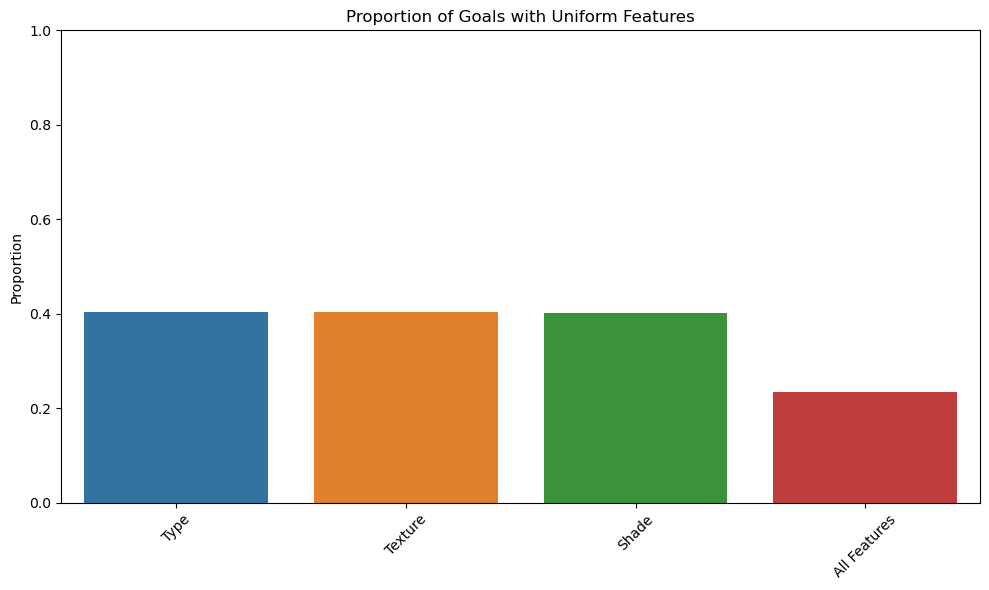

In [165]:
results = analyze_uniformity_states(goals_sim.flatten())

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

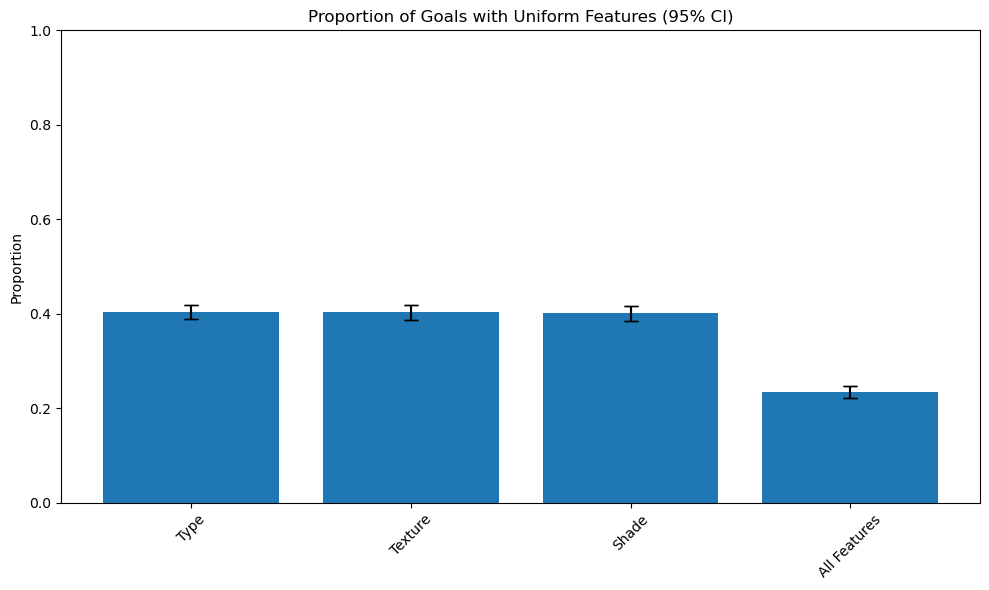

Type: 40.40% (95% CI: 38.90% - 41.95%)
Texture: 40.38% (95% CI: 38.80% - 41.77%)
Shade: 40.12% (95% CI: 38.55% - 41.63%)
All Features: 23.50% (95% CI: 22.25% - 24.98%)


In [166]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from rllib.shapeworld import State

def bootstrap_proportion(data, n_bootstraps=1000):
    """
    Calculate bootstrapped confidence intervals for a proportion.
    """
    proportions = []
    for _ in tqdm(range(n_bootstraps), desc="Bootstrapping"):
        # Resample with replacement
        resample = np.random.choice(data, size=len(data), replace=True)
        # Calculate proportion for this bootstrap sample
        proportions.append(resample.mean())
    
    # Calculate 95% confidence interval
    lower = np.percentile(proportions, 2.5)
    upper = np.percentile(proportions, 97.5)
    return lower, upper

def analyze_uniformity_states_with_ci(goal_states, n_bootstraps=1000):
    """
    Analyze uniformity of each feature with confidence intervals for a list of State objects.
    
    Args:
        goal_states: List of State objects
        n_bootstraps: Number of bootstrap samples to generate
    """
    # Initialize arrays to store uniformity results
    type_uniform = np.zeros(len(goal_states), dtype=bool)
    texture_uniform = np.zeros(len(goal_states), dtype=bool)
    shade_uniform = np.zeros(len(goal_states), dtype=bool)
    all_uniform = np.zeros(len(goal_states), dtype=bool)
    
    # Check each state
    for i, state in enumerate(goal_states):
        # Get shapes from state
        shapes = [state.shape1, state.shape2, state.shape3]
        
        # Check if all shapes have same type
        type_uniform[i] = all(s.sides == shapes[0].sides for s in shapes)
        
        # Check if all shapes have same texture
        texture_uniform[i] = all(s.texture == shapes[0].texture for s in shapes)
        
        # Check if all shapes have same shade
        shade_uniform[i] = all(s.shade == shapes[0].shade for s in shapes)
        
        # Check if all features are uniform
        all_uniform[i] = (type_uniform[i] and texture_uniform[i] and shade_uniform[i])
    
    # Calculate proportions and confidence intervals
    results = {
        'Type': {
            'proportion': type_uniform.mean(),
            'ci': bootstrap_proportion(type_uniform, n_bootstraps)
        },
        'Texture': {
            'proportion': texture_uniform.mean(),
            'ci': bootstrap_proportion(texture_uniform, n_bootstraps)
        },
        'Shade': {
            'proportion': shade_uniform.mean(),
            'ci': bootstrap_proportion(shade_uniform, n_bootstraps)
        },
        'All Features': {
            'proportion': all_uniform.mean(),
            'ci': bootstrap_proportion(all_uniform, n_bootstraps)
        }
    }
    
    # Create visualization with error bars
    plt.figure(figsize=(10, 6))
    
    # Extract data for plotting
    features = list(results.keys())
    proportions = [results[f]['proportion'] for f in features]
    ci_lower = [results[f]['ci'][0] for f in features]
    ci_upper = [results[f]['ci'][1] for f in features]
    errors = [proportions[i] - ci_lower[i] for i in range(len(proportions))]
    
    # Create bar plot with error bars
    bars = plt.bar(features, proportions, yerr=errors, capsize=5)
    
    # Add error bars
    plt.errorbar(features, proportions, yerr=errors, fmt='none', 
                 ecolor='black', capsize=5)
    
    plt.title('Proportion of Goals with Uniform Features (95% CI)')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    
    # Print the results with confidence intervals
    for feature, data in results.items():
        print(f"{feature}: {data['proportion']:.2%} (95% CI: {data['ci'][0]:.2%} - {data['ci'][1]:.2%})")
    
    return results

# Example usage:
results = analyze_uniformity_states_with_ci(goals_sim.flatten())

In [114]:
def find_goal_index(row, conceptual_probs_df):
    """Find the index of a goal configuration in the conceptual probabilities dataframe."""
    # Create query for each shape
    query = True
    for i in range(3):  # For each shape position
        for prop in ['type', 'shade', 'texture']:
            # Map column names between dataframes
            selected_col = f'shape_{i}_{prop}'
            prob_col = f'shape{i+1}_{"sides" if prop == "type" else prop}'
            
            value = row[selected_col]
            query &= (conceptual_probs_df[prob_col] == value)
    
    matching_rows = conceptual_probs_df[query]
    
    if len(matching_rows) == 0:
        print(f"\nNo matching configuration found for:")
        print(f"Participant: {row['participant_id']}, Trial: {row['trial_number']}")
        for i in range(3):
            print(f"Shape {i}: {row[f'shape_{i}_type']}, {row[f'shape_{i}_shade']}, {row[f'shape_{i}_texture']}")
        raise ValueError("No matching configuration found in conceptual probabilities")
    
    return matching_rows.index[0]



In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rllib.shapeworld import State

def find_goal_index_from_state(state: State, value_function: pd.DataFrame) -> int:
    """
    Find the index of a goal state in the value function DataFrame.
    
    Args:
        state: A State object containing three shapes
        value_function: DataFrame containing the value function
        
    Returns:
        int: Index of the matching row in value_function
    """
    # Convert state to the format used in value_function
    shape1 = state.shape1
    shape2 = state.shape2
    shape3 = state.shape3
    
    # Find matching row
    mask = (
        (value_function['shape1_sides'] == shape1.sides) &
        (value_function['shape1_shade'] == shape1.shade) &
        (value_function['shape1_texture'] == shape1.texture) &
        (value_function['shape2_sides'] == shape2.sides) &
        (value_function['shape2_shade'] == shape2.shade) &
        (value_function['shape2_texture'] == shape2.texture) &
        (value_function['shape3_sides'] == shape3.sides) &
        (value_function['shape3_shade'] == shape3.shade) &
        (value_function['shape3_texture'] == shape3.texture)
    )
    
    matching_indices = value_function[mask].index
    if len(matching_indices) == 0:
        raise ValueError(f"Could not find matching state in value function: {state}")
    return matching_indices[0]

def calculate_costs_for_states(goal_states: list[State], value_function_path: str) -> np.ndarray:
    """
    Calculate costs for a list of State objects using the value function.
    
    Args:
        goal_states: List of State objects
        value_function_path: Path to the value function CSV file
        
    Returns:
        np.ndarray: Array of costs for each state
    """
    # Load value function
    value_function = pd.read_csv(value_function_path)
    
    # Remove summary rows
    value_function = value_function[value_function['shape1_sides'] != 'SUMMARY']
    
    # Calculate costs for each state
    costs = []
    for state in goal_states:
        goal_index = find_goal_index_from_state(state, value_function)
        cost = value_function.loc[goal_index, 'value']
        costs.append(-1 * cost)  # Convert value to cost
    
    return np.array(costs)

def plot_cost_distribution(costs: np.ndarray, title: str = "Distribution of Goal Costs"):
    """
    Plot the distribution of costs using a violin plot.
    
    Args:
        costs: Array of costs
        title: Title for the plot
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(x=costs, stat='percent', bins=20,)
    plt.ylabel('Cost')
    plt.title(title)
    plt.show()
    
    # Print summary statistics
    print(f"Mean cost: {np.mean(costs):.2f}")
    print(f"Median cost: {np.median(costs):.2f}")
    print(f"Min cost: {np.min(costs):.2f}")
    print(f"Max cost: {np.max(costs):.2f}")
    print(f"Standard deviation: {np.std(costs):.2f}")

# Example usage:
# 1. Load your goal states
# goal_states = [...]  # Your list of State objects

# 2. Calculate costs
# costs = calculate_costs_for_states(goal_states, '../simulations/value-functions/goal_value_function_mean.csv')

# 3. Plot the distribution
# plot_cost_distribution(costs, "Distribution of Goal Costs for Conceptual Model Winners")

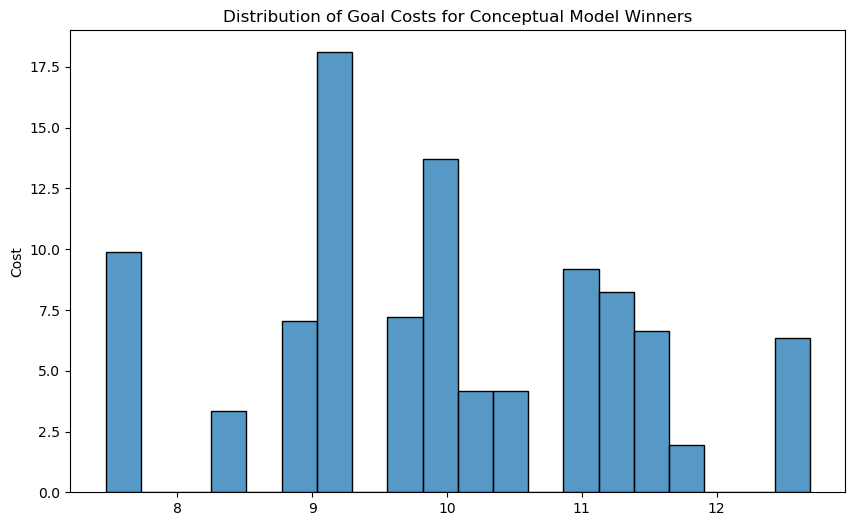

Mean cost: 9.98
Median cost: 9.92
Min cost: 7.47
Max cost: 12.69
Standard deviation: 1.35


In [134]:
# Calculate costs for conceptual model winners
costs = calculate_costs_for_states(goals_sim, '../simulations/value-functions/goal_value_function_mean.csv')

# Plot the distribution
plot_cost_distribution(costs, "Distribution of Goal Costs for Conceptual Model Winners")